# 06 TEMPTED–MEFISTO comparison and plotting

1. finds the newest complete TEMPTED run
2. finds the complete MEFISTO run 
3. verifies identical held-out subjects in every paired batch
4. aligns factor/component order and sign across repeated fits
5. builds subject scores, sample trajectories, consensus feature loadings, and alignment tables
6. saves all reproducibility tables
7. produces held-out performance, latent-space, feature-comparison, and Greengenes taxonomy plots.

In [1]:
from datetime import datetime
from itertools import permutations
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import SymLogNorm

PRIMARY_METRIC = "balanced_accuracy"
EXPECTED_BATCHES = 20
EXPECTED_DIMENSIONS = 5
SELECTED_BATCH = ""

LABEL_MAP = {
    "FIN": "FIN/EST",
    "FINLAND": "FIN/EST",
    "EST": "FIN/EST",
    "ESTONIA": "FIN/EST",
    "RUS": "RUS",
    "RUSSIA": "RUS",
}
GROUP_ORDER = ["FIN/EST", "RUS"]
GROUP_COLORS = {"FIN/EST": "#0072E8", "RUS": "#F03B20"}

root = Path(".") if Path("data").exists() else Path("..")
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_data_folder = root / "data" / "plot_data" / run_id
output = root / "data" / "figures" / run_id
plot_data_folder.mkdir(parents=True, exist_ok=True)
output.mkdir(parents=True, exist_ok=True)

print("Plot data:", plot_data_folder)
print("Figures:", output)


Plot data: ../data/plot_data/20260809_182023
Figures: ../data/figures/20260809_182023


## Helpers


In [2]:
def normalize_group(value):
    key = str(value).strip().upper()
    return LABEL_MAP.get(key, str(value).strip())


def display_dimension(method, column):
    number = str(column).split("_")[-1]
    return f"Component {number}" if method == "TEMPTED" else f"Factor {number}"


def factor_columns(frame):
    return sorted(
        [
            column
            for column in frame.columns
            if re.fullmatch(r"factor_[0-9]+", str(column))
            and pd.to_numeric(frame[column], errors="coerce").notna().any()
        ],
        key=lambda name: int(name.split("_")[-1]),
    )


def existing_table(folder, stem, required=True):
    folder = Path(folder)
    for path in [folder / f"{stem}.csv.gz", folder / f"{stem}.csv"]:
        if path.exists():
            return path
    if required:
        raise FileNotFoundError(f"Missing {stem} in {folder}")
    return None


def read_table(path):
    return pd.read_csv(path)


def load_feature_loadings(folder):
    frame = read_table(existing_table(folder, "feature_loadings"))
    first = frame.columns[0]
    if first != "feature_id":
        frame = frame.rename(columns={first: "feature_id"})
    frame["feature_id"] = frame["feature_id"].astype(str)
    return frame


def run_is_complete(run, method):
    run = Path(run)
    batches = sorted(
        path for path in run.iterdir()
        if path.is_dir() and re.fullmatch(r"batch_[0-9]+", path.name)
    )
    if len(batches) != EXPECTED_BATCHES:
        return False

    for folder in batches:
        loadings_path = existing_table(folder, "feature_loadings", required=False)
        scores_path = existing_table(folder, "test_subject_scores", required=False)
        predictions_path = existing_table(folder, "predictions", required=False)
        if loadings_path is None or scores_path is None or predictions_path is None:
            return False
        if len(factor_columns(read_table(loadings_path))) != EXPECTED_DIMENSIONS:
            return False

        if method == "MEFISTO":
            train_path = existing_table(folder, "train_sample_factors", required=False)
            test_path = existing_table(folder, "test_sample_factors", required=False)
            if train_path is None or test_path is None:
                return False
            if len(factor_columns(read_table(train_path))) != EXPECTED_DIMENSIONS:
                return False
            if len(factor_columns(read_table(test_path))) != EXPECTED_DIMENSIONS:
                return False

    return True


def newest_complete_run(folder, method):
    folder = Path(folder)
    runs = sorted(
        (path for path in folder.iterdir() if path.is_dir()),
        reverse=True,
    )
    for run in runs:
        if run_is_complete(run, method):
            return run
    raise FileNotFoundError(
        f"No complete {EXPECTED_DIMENSIONS}-dimension, "
        f"{EXPECTED_BATCHES}-batch {method} run found in {folder}"
    )


def robust_limits(values, padding=0.08, lower_quantile=0.01, upper_quantile=0.99):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1, 1)
    low, high = np.quantile(values, [lower_quantile, upper_quantile])
    if low == high:
        spread = max(abs(low), 1) * 0.1
        return low - spread, high + spread
    margin = (high - low) * padding
    return low - margin, high + margin


def save_figure(figure, filename):
    path = output / filename
    figure.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(figure)
    print("Saved:", path)


def normalized_confusion(rows):
    matrix = (
        rows.pivot(index="truth", columns="predicted", values="count")
        .reindex(index=GROUP_ORDER, columns=GROUP_ORDER, fill_value=0)
        .fillna(0)
    )
    percentages = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100
    return matrix, percentages


def finite_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    if keep.sum() < 3 or np.std(x[keep]) == 0 or np.std(y[keep]) == 0:
        return np.nan
    return np.corrcoef(x[keep], y[keep])[0, 1]


def zscore(values):
    values = pd.to_numeric(values, errors="coerce").to_numpy(float)
    mean = np.nanmean(values)
    sd = np.nanstd(values)
    if not np.isfinite(sd) or sd == 0:
        return values - mean
    return (values - mean) / sd


def best_alignment(reference, current, minimum_shared=10):
    reference_factors = factor_columns(reference)
    current_factors = factor_columns(current)
    shared = sorted(set(reference["feature_id"]) & set(current["feature_id"]))

    if len(shared) < minimum_shared:
        raise ValueError(
            f"Too few shared genera to align loading matrices: {len(shared)}"
        )

    ref = reference.set_index("feature_id").loc[shared]
    cur = current.set_index("feature_id").loc[shared]
    correlation = np.full(
        (len(reference_factors), len(current_factors)),
        np.nan,
        dtype=float,
    )

    for i, ref_factor in enumerate(reference_factors):
        for j, cur_factor in enumerate(current_factors):
            correlation[i, j] = finite_corr(
                ref[ref_factor].to_numpy(float),
                cur[cur_factor].to_numpy(float),
            )

    best_perm = None
    best_score = -np.inf

    for perm in permutations(range(len(current_factors)), len(reference_factors)):
        values = np.array(
            [correlation[i, perm[i]] for i in range(len(reference_factors))],
            dtype=float,
        )
        if not np.isfinite(values).all():
            continue
        score = np.abs(values).sum()
        if score > best_score:
            best_score = score
            best_perm = perm

    if best_perm is None:
        raise ValueError("Could not find a finite factor alignment.")

    aligned = pd.DataFrame({"feature_id": current["feature_id"].astype(str)})
    signs = []

    for i, ref_factor in enumerate(reference_factors):
        j = best_perm[i]
        sign = -1 if correlation[i, j] < 0 else 1
        signs.append(sign)
        aligned[ref_factor] = (
            pd.to_numeric(current[current_factors[j]], errors="coerce").to_numpy(float)
            * sign
        )

    return aligned, best_score, best_perm, signs, correlation


def representative_reference(loadings_by_batch):
    names = list(loadings_by_batch)
    scores = []

    for i, name_i in enumerate(names):
        pair_scores = []
        for j, name_j in enumerate(names):
            if i == j:
                continue
            try:
                _, score, *_ = best_alignment(
                    loadings_by_batch[name_i],
                    loadings_by_batch[name_j],
                )
                if np.isfinite(score):
                    pair_scores.append(score)
            except ValueError:
                pass
        scores.append(np.mean(pair_scores) if pair_scores else -np.inf)

    index = int(np.argmax(scores))
    return names[index], loadings_by_batch[names[index]]


## Resolve matched runs and verify the 20 paired splits


In [3]:
tempted_run = newest_complete_run(root / "data" / "tempted", "TEMPTED")

tempted_metrics_all = pd.read_csv(tempted_run / "all_metrics.csv", dtype={"split_run": str})
if "split_run" not in tempted_metrics_all or tempted_metrics_all["split_run"].nunique() != 1:
    raise ValueError("TEMPTED run must contain exactly one split_run identifier.")

split_run = str(tempted_metrics_all["split_run"].iloc[0])

mefisto_run = None
for candidate in sorted(
    (path for path in (root / "data" / "mefisto").iterdir() if path.is_dir()),
    reverse=True,
):
    metrics_path = candidate / "all_metrics.csv"
    if not metrics_path.exists() or not run_is_complete(candidate, "MEFISTO"):
        continue

    candidate_metrics = pd.read_csv(metrics_path, dtype={"split_run": str})
    if (
        "split_run" in candidate_metrics
        and candidate_metrics["split_run"].nunique() == 1
        and str(candidate_metrics["split_run"].iloc[0]) == split_run
    ):
        mefisto_run = candidate
        break

if mefisto_run is None:
    raise FileNotFoundError(
        "No complete five-factor MEFISTO run uses the same split set as TEMPTED."
    )

tempted_batches = {
    path.name for path in tempted_run.iterdir()
    if path.is_dir() and re.fullmatch(r"batch_[0-9]+", path.name)
}
mefisto_batches = {
    path.name for path in mefisto_run.iterdir()
    if path.is_dir() and re.fullmatch(r"batch_[0-9]+", path.name)
}
batch_names = sorted(tempted_batches & mefisto_batches)

if len(batch_names) != EXPECTED_BATCHES:
    raise ValueError(
        f"Expected {EXPECTED_BATCHES} matched model batches; found {len(batch_names)}."
    )

selected_batch = SELECTED_BATCH or batch_names[0]
if selected_batch not in batch_names:
    raise ValueError(f"Unknown SELECTED_BATCH: {selected_batch}")

splits_run = root / "data" / "splits" / split_run
split_batch = splits_run / selected_batch

if not split_batch.exists():
    raise FileNotFoundError(f"Split batch not found: {split_batch}")

# Verify exact held-out subject identity and truth labels in every pair.
for batch in batch_names:
    t = read_table(existing_table(tempted_run / batch, "predictions"))
    m = read_table(existing_table(mefisto_run / batch, "predictions"))

    for frame in [t, m]:
        frame["subject_id"] = frame["subject_id"].astype(str)
        frame["truth"] = frame["truth"].astype(str)

    t = t[["subject_id", "truth"]].sort_values("subject_id").reset_index(drop=True)
    m = m[["subject_id", "truth"]].sort_values("subject_id").reset_index(drop=True)

    if not t.equals(m):
        raise ValueError(
            f"{batch}: TEMPTED and MEFISTO do not contain identical "
            "held-out subjects and truth labels."
        )

print("Split run:", split_run)
print("TEMPTED:", tempted_run)
print("MEFISTO:", mefisto_run)
print("Selected batch:", selected_batch)
print("Matched batches:", len(batch_names))


Split run: 20260809_010356
TEMPTED: ../data/tempted/20260809_010443
MEFISTO: ../data/mefisto/20260809_011140
Selected batch: batch_001
Matched batches: 20


## Build aligned analysis tables

Factor order and sign are not intrinsically identifiable. The notebook therefore:

- chooses a representative reference fit within each method;
- aligns all 20 fits within each method;
- takes median feature loadings across the aligned fits;
- matches the five MEFISTO consensus factors to the five TEMPTED consensus components;
- reorders and sign-corrects the MEFISTO consensus loadings into TEMPTED component order.

Subject and sample-level values remain on their original method-specific scales; where direct comparison is needed later, the plots standardize them explicitly.


In [4]:
# Selected split data and transformed TEMPTED matrix.
train_meta = read_table(existing_table(split_batch, "train_metadata"))
test_meta = read_table(existing_table(split_batch, "test_metadata"))
metadata = pd.concat([train_meta, test_meta], ignore_index=True)

metadata["sample_id"] = metadata["sample_id"].astype(str)
metadata["subject_id"] = metadata["subject_id"].astype(str)
metadata["label"] = metadata["label"].map(normalize_group)
metadata["time"] = pd.to_numeric(metadata["time"], errors="coerce")


def read_matrix_table(folder, stem):
    path = existing_table(folder, stem, required=False)
    if path is None:
        return None
    frame = read_table(path)
    frame["sample_id"] = frame["sample_id"].astype(str)
    return frame.set_index("sample_id").apply(pd.to_numeric, errors="coerce")


def read_tempted_matrix(folder, stem):
    preferred = read_matrix_table(folder, f"{stem}_tempted_clr")
    if preferred is not None:
        return preferred
    old = read_matrix_table(folder, f"{stem}_rclr")
    if old is not None:
        return old
    raise FileNotFoundError(f"No TEMPTED transformed matrix found in {folder}")


train_tempted = read_tempted_matrix(split_batch, "train")
test_tempted = read_tempted_matrix(split_batch, "test")
tempted_values = pd.concat([train_tempted, test_tempted])
tempted_values = tempted_values.loc[metadata["sample_id"]]


# Load all feature-loading batches.
method_loadings = {
    "TEMPTED": {
        batch: load_feature_loadings(tempted_run / batch)
        for batch in batch_names
    },
    "MEFISTO": {
        batch: load_feature_loadings(mefisto_run / batch)
        for batch in batch_names
    },
}

reference_batch = {}
reference_loadings = {}
aligned_within_method = {}

for method in ["TEMPTED", "MEFISTO"]:
    reference_batch[method], reference_loadings[method] = representative_reference(
        method_loadings[method]
    )
    aligned_within_method[method] = {}

    for batch in batch_names:
        aligned, *_ = best_alignment(
            reference_loadings[method],
            method_loadings[method][batch],
        )
        aligned_within_method[method][batch] = aligned

    print(f"{method} reference:", reference_batch[method])


def median_aligned_loadings(loadings_by_batch):
    rows = []
    for batch, frame in loadings_by_batch.items():
        current = frame.copy()
        current["batch"] = batch
        rows.append(current)

    combined = pd.concat(rows, ignore_index=True)
    factors = factor_columns(combined)

    return (
        combined.groupby("feature_id", as_index=False)[factors]
        .median(numeric_only=True)
    )


tempted_median = median_aligned_loadings(aligned_within_method["TEMPTED"])
mefisto_median_native = median_aligned_loadings(aligned_within_method["MEFISTO"])

tempted_factors = factor_columns(tempted_median)
mefisto_factors = factor_columns(mefisto_median_native)

shared = sorted(
    set(tempted_median["feature_id"])
    & set(mefisto_median_native["feature_id"])
)

t_indexed = tempted_median.set_index("feature_id").loc[shared]
m_indexed = mefisto_median_native.set_index("feature_id").loc[shared]

cross_corr = np.full(
    (len(tempted_factors), len(mefisto_factors)),
    np.nan,
    dtype=float,
)

for i, t_factor in enumerate(tempted_factors):
    for j, m_factor in enumerate(mefisto_factors):
        cross_corr[i, j] = finite_corr(
            t_indexed[t_factor].to_numpy(float),
            m_indexed[m_factor].to_numpy(float),
        )

best_perm = None
best_score = -np.inf

for perm in permutations(range(len(mefisto_factors)), len(tempted_factors)):
    values = np.array(
        [cross_corr[i, perm[i]] for i in range(len(tempted_factors))],
        dtype=float,
    )
    if not np.isfinite(values).all():
        continue
    score = np.abs(values).sum()
    if score > best_score:
        best_score = score
        best_perm = perm

if best_perm is None:
    raise ValueError("Could not determine cross-method factor matching.")

alignment_rows = []
for i, t_factor in enumerate(tempted_factors):
    j = best_perm[i]
    correlation = cross_corr[i, j]
    alignment_rows.append(
        {
            "tempted_factor": t_factor,
            "mefisto_factor": mefisto_factors[j],
            "correlation": correlation,
            "sign": -1 if correlation < 0 else 1,
        }
    )

alignment = pd.DataFrame(alignment_rows)
display(alignment)


# Reorder/sign-correct every MEFISTO loading fit into TEMPTED order.
aligned_mefisto = {}

for batch, current in aligned_within_method["MEFISTO"].items():
    result = pd.DataFrame({"feature_id": current["feature_id"].astype(str)})

    for row in alignment.itertuples(index=False):
        result[row.tempted_factor] = (
            pd.to_numeric(current[row.mefisto_factor], errors="coerce").to_numpy(float)
            * row.sign
        )

    aligned_mefisto[batch] = result


# Build the complete repeated-loading table and final median loadings.
loading_rows = []

for batch in batch_names:
    tempted = aligned_within_method["TEMPTED"][batch].copy()
    tempted["method"] = "TEMPTED"
    tempted["batch"] = batch
    loading_rows.append(tempted)

    mefisto = aligned_mefisto[batch].copy()
    mefisto["method"] = "MEFISTO"
    mefisto["batch"] = batch
    loading_rows.append(mefisto)

loading_resamples = pd.concat(loading_rows, ignore_index=True)

feature_loadings = (
    loading_resamples
    .groupby(["method", "feature_id"], as_index=False)[tempted_factors]
    .median(numeric_only=True)
)



# Subject-level and sample-level factor tables from the selected batch.
#
# Because the within-method reference may be any representative batch,
# the selected batch must use the SAME permutation/sign transformation
# as its feature-loading matrix. We then apply the cross-method MEFISTO
# matching and expose both methods as factor_1 ... factor_5 in matched order.

def load_subject_scores(folder):
    frame = read_table(existing_table(folder, "test_subject_scores"))
    frame["subject_id"] = frame["subject_id"].astype(str)
    frame["label"] = frame["label"].map(normalize_group)
    return frame


def transform_factor_table(frame, reference_factors, current_factors, perm, signs):
    result = frame[[column for column in frame.columns if column not in current_factors]].copy()

    for i, target_factor in enumerate(reference_factors):
        source_factor = current_factors[perm[i]]
        result[target_factor] = (
            pd.to_numeric(frame[source_factor], errors="coerce").to_numpy(float)
            * signs[i]
        )

    return result


# Determine selected-batch within-method mappings.
selected_tempted_raw_loadings = load_feature_loadings(
    tempted_run / selected_batch
)
(
    selected_tempted_loadings,
    _,
    tempted_selected_perm,
    tempted_selected_signs,
    _,
) = best_alignment(
    reference_loadings["TEMPTED"],
    selected_tempted_raw_loadings,
)

selected_mefisto_raw_loadings = load_feature_loadings(
    mefisto_run / selected_batch
)
(
    selected_mefisto_reference_order,
    _,
    mefisto_selected_perm,
    mefisto_selected_signs,
    _,
) = best_alignment(
    reference_loadings["MEFISTO"],
    selected_mefisto_raw_loadings,
)


# Held-out subject scores: first align each selected fit to its own method
# reference, then reorder/sign-correct MEFISTO into TEMPTED component order.
tempted_scores_raw = load_subject_scores(
    tempted_run / selected_batch
)
mefisto_scores_raw = load_subject_scores(
    mefisto_run / selected_batch
)

tempted_current_factors = factor_columns(tempted_scores_raw)
mefisto_current_factors = factor_columns(mefisto_scores_raw)

tempted_scores = transform_factor_table(
    tempted_scores_raw,
    factor_columns(reference_loadings["TEMPTED"]),
    tempted_current_factors,
    tempted_selected_perm,
    tempted_selected_signs,
)

mefisto_scores_reference_order = transform_factor_table(
    mefisto_scores_raw,
    factor_columns(reference_loadings["MEFISTO"]),
    mefisto_current_factors,
    mefisto_selected_perm,
    mefisto_selected_signs,
)

mefisto_scores = mefisto_scores_reference_order[
    ["subject_id", "label"]
].copy()

for row in alignment.itertuples(index=False):
    mefisto_scores[row.tempted_factor] = (
        pd.to_numeric(
            mefisto_scores_reference_order[row.mefisto_factor],
            errors="coerce",
        ).to_numpy(float)
        * row.sign
    )

subject_scores = pd.concat(
    [
        tempted_scores.assign(method="TEMPTED"),
        mefisto_scores.assign(method="MEFISTO"),
    ],
    ignore_index=True,
)


# TEMPTED sample-level projection using the selected batch's feature loadings
# already aligned into the representative TEMPTED reference order.
shared_features_projection = [
    feature
    for feature in selected_tempted_loadings["feature_id"]
    if feature in tempted_values.columns
]

W = (
    selected_tempted_loadings
    .set_index("feature_id")
    .loc[shared_features_projection, tempted_factors]
    .to_numpy(float)
)
X = (
    tempted_values
    .loc[:, shared_features_projection]
    .to_numpy(float)
)
projected = X @ W

tempted_samples = pd.DataFrame(
    projected,
    columns=tempted_factors,
)
tempted_samples.insert(
    0,
    "sample_id",
    metadata["sample_id"].to_numpy(),
)
tempted_samples["subject_id"] = metadata["subject_id"].to_numpy()
tempted_samples["time"] = metadata["time"].to_numpy()
tempted_samples["label"] = metadata["label"].to_numpy()
tempted_samples["method"] = "TEMPTED"


# MEFISTO fitted train/test sample factors from the same selected batch.
def load_mefisto_samples(folder):
    train = read_table(existing_table(folder, "train_sample_factors"))
    test = read_table(existing_table(folder, "test_sample_factors"))
    frame = pd.concat([train, test], ignore_index=True)

    frame["sample_id"] = frame["sample_id"].astype(str)
    frame["subject_id"] = frame["subject_id"].astype(str)
    frame["time"] = pd.to_numeric(frame["time"], errors="coerce")
    frame["label"] = frame["label"].map(normalize_group)

    return frame


mefisto_samples_raw = load_mefisto_samples(
    mefisto_run / selected_batch
)

mefisto_sample_current_factors = factor_columns(
    mefisto_samples_raw
)

mefisto_samples_reference_order = transform_factor_table(
    mefisto_samples_raw,
    factor_columns(reference_loadings["MEFISTO"]),
    mefisto_sample_current_factors,
    mefisto_selected_perm,
    mefisto_selected_signs,
)

mefisto_samples = mefisto_samples_reference_order[
    ["sample_id", "subject_id", "time", "label"]
].copy()

for row in alignment.itertuples(index=False):
    mefisto_samples[row.tempted_factor] = (
        pd.to_numeric(
            mefisto_samples_reference_order[row.mefisto_factor],
            errors="coerce",
        ).to_numpy(float)
        * row.sign
    )

mefisto_samples["method"] = "MEFISTO"

sample_factors = pd.concat(
    [tempted_samples, mefisto_samples],
    ignore_index=True,
    sort=False,
)


# Trajectory summaries: 12 equal-width bins within each method/factor/group.
trajectory_rows = []

for method in ["TEMPTED", "MEFISTO"]:
    method_frame = sample_factors[sample_factors["method"] == method].copy()

    # Both methods are now explicitly represented in matched TEMPTED order.
    method_factors = tempted_factors

    for factor in method_factors:
        values = pd.to_numeric(method_frame[factor], errors="coerce")
        times = pd.to_numeric(method_frame["time"], errors="coerce")

        valid = np.isfinite(values) & np.isfinite(times)
        temp = method_frame.loc[valid, ["label"]].copy()
        temp["time"] = times[valid].to_numpy()
        temp["value"] = values[valid].to_numpy()

        if temp.empty:
            continue

        temp["time_bin"] = pd.cut(
            temp["time"],
            bins=12,
            include_lowest=True,
            labels=False,
            duplicates="drop",
        )

        for (label, time_bin), group in temp.groupby(["label", "time_bin"], dropna=True):
            if len(group) < 3:
                continue

            trajectory_rows.append(
                {
                    "method": method,
                    "factor": factor,
                    "label": label,
                    "time_bin": int(time_bin),
                    "time": group["time"].median(),
                    "median": group["value"].median(),
                    "lower": group["value"].quantile(0.25),
                    "upper": group["value"].quantile(0.75),
                    "n": len(group),
                }
            )

trajectory_summary = pd.DataFrame(trajectory_rows)

# Save reproducibility tables.
alignment.to_csv(plot_data_folder / "factor_alignment.csv", index=False)
subject_scores.to_csv(plot_data_folder / "subject_scores.csv", index=False)
sample_factors.to_csv(plot_data_folder / "sample_factors.csv", index=False)
feature_loadings.to_csv(plot_data_folder / "feature_loadings.csv", index=False)
trajectory_summary.to_csv(plot_data_folder / "trajectory_summary.csv", index=False)
loading_resamples.to_csv(plot_data_folder / "loading_resamples.csv", index=False)

source_manifest = pd.DataFrame(
    {
        "item": [
            "splits_run",
            "split_run",
            "tempted_run",
            "mefisto_run",
            "batch",
            "batches",
            "dimensions",
            "tempted_reference_batch",
            "mefisto_reference_batch",
        ],
        "value": [
            str(splits_run),
            split_run,
            str(tempted_run),
            str(mefisto_run),
            selected_batch,
            EXPECTED_BATCHES,
            EXPECTED_DIMENSIONS,
            reference_batch["TEMPTED"],
            reference_batch["MEFISTO"],
        ],
    }
)
source_manifest.to_csv(plot_data_folder / "source_manifest.csv", index=False)

print("Saved aligned plot tables:", plot_data_folder)


TEMPTED reference: batch_006
MEFISTO reference: batch_006


,tempted_factor,mefisto_factor,correlation,sign
0,factor_1,factor_1,0.759557,1
1,factor_2,factor_3,0.879983,1
2,factor_3,factor_4,-0.158906,-1
3,factor_4,factor_5,0.619920,1
4,factor_5,factor_2,-0.600136,-1


Saved aligned plot tables: ../data/plot_data/20260809_182023


## Held-out performance and classification


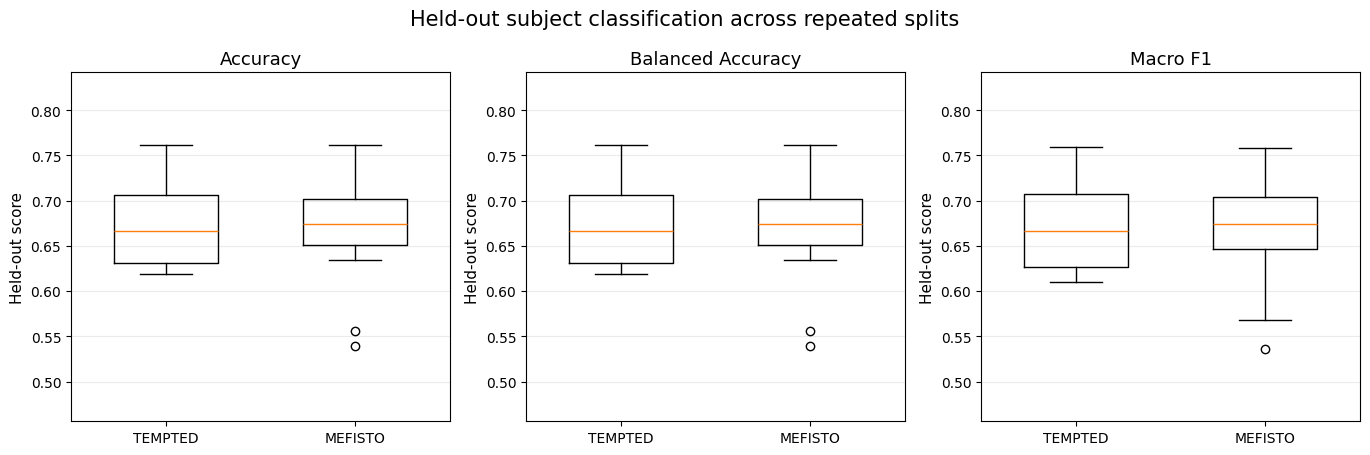

Saved: ../data/figures/20260809_182023/07_classification_metrics.png


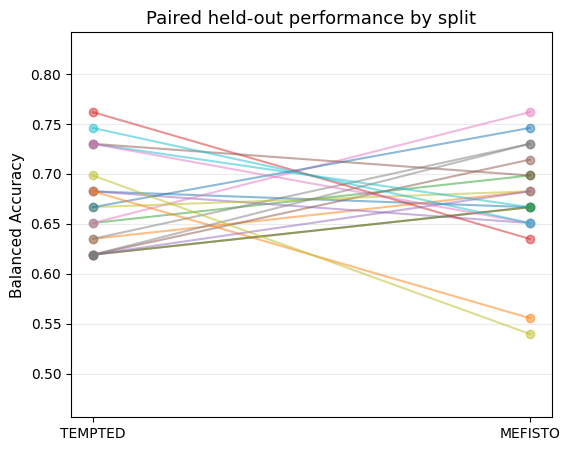

Saved: ../data/figures/20260809_182023/07_paired_batch_performance.png


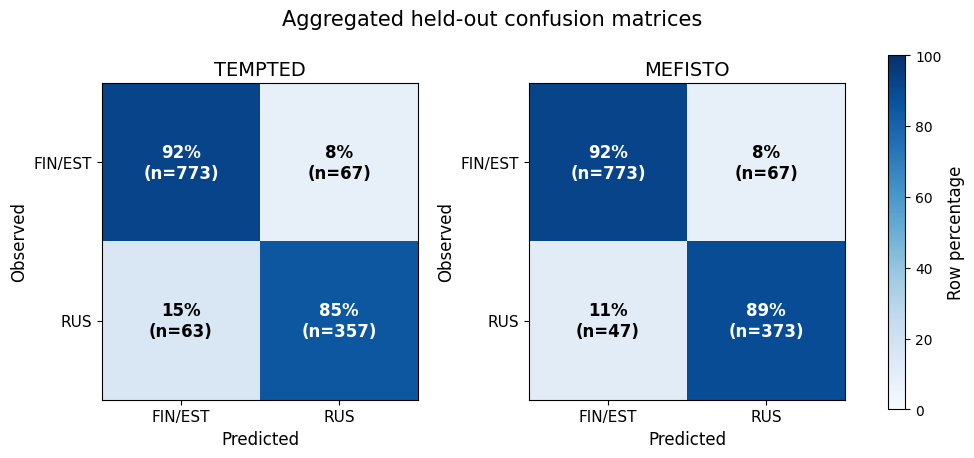

Saved: ../data/figures/20260809_182023/07_confusion_matrices.png


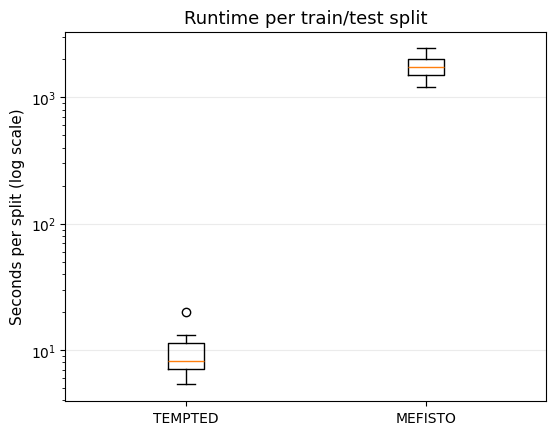

Saved: ../data/figures/20260809_182023/07_runtime.png


In [5]:
# ------------------------------------------------------------------
# Build paired performance / prediction tables
# ------------------------------------------------------------------

common_batches = batch_names

metric_rows = []
prediction_rows = []

for method, run in [
    ("TEMPTED", tempted_run),
    ("MEFISTO", mefisto_run),
]:

    for batch in common_batches:

        folder = run / batch

        metric_path = (
            folder
            / "metrics.csv"
        )

        if not metric_path.exists():
            raise FileNotFoundError(
                f"Missing metrics.csv for {method} {batch}: "
                f"{metric_path}"
            )

        metric = pd.read_csv(
            metric_path
        ).copy()

        metric["method"] = method
        metric["batch"] = batch

        metric_rows.append(
            metric
        )


        prediction = read_table(
            existing_table(
                folder,
                "predictions",
            )
        ).copy()

        prediction["subject_id"] = (
            prediction["subject_id"]
            .astype(str)
        )

        prediction["truth"] = (
            prediction["truth"]
            .astype(str)
        )

        prediction["predicted"] = (
            prediction["predicted"]
            .astype(str)
        )

        prediction["method"] = method
        prediction["batch"] = batch

        prediction_rows.append(
            prediction
        )


metrics = pd.concat(
    metric_rows,
    ignore_index=True,
)

predictions = pd.concat(
    prediction_rows,
    ignore_index=True,
)


# ------------------------------------------------------------------
# Verify paired held-out subjects
# ------------------------------------------------------------------

for batch in common_batches:

    tempted_check = (
        predictions[
            (
                predictions["batch"]
                == batch
            )
            & (
                predictions["method"]
                == "TEMPTED"
            )
        ][
            [
                "subject_id",
                "truth",
            ]
        ]
        .sort_values(
            "subject_id"
        )
        .reset_index(
            drop=True
        )
    )

    mefisto_check = (
        predictions[
            (
                predictions["batch"]
                == batch
            )
            & (
                predictions["method"]
                == "MEFISTO"
            )
        ][
            [
                "subject_id",
                "truth",
            ]
        ]
        .sort_values(
            "subject_id"
        )
        .reset_index(
            drop=True
        )
    )

    if not tempted_check.equals(
        mefisto_check
    ):
        raise ValueError(
            f"{batch}: TEMPTED and MEFISTO do not contain "
            "identical held-out subjects and truth labels."
        )


# ------------------------------------------------------------------
# Normalize labels and aggregate confusion counts
# ------------------------------------------------------------------

predictions["truth"] = (
    predictions["truth"]
    .map(
        normalize_group
    )
)

predictions["predicted"] = (
    predictions["predicted"]
    .map(
        normalize_group
    )
)

confusion = (
    predictions
    .groupby(
        [
            "method",
            "truth",
            "predicted",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "count"
        }
    )
)


# ------------------------------------------------------------------
# Classification metrics across repeated splits
# ------------------------------------------------------------------

metric_columns = [
    column
    for column in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]
    if column
    in metrics.columns
]

figure, axes = plt.subplots(
    1,
    len(metric_columns),
    figsize=(
        4.6
        * len(metric_columns),
        4.6,
    ),
)

axes = np.atleast_1d(
    axes
)

all_metric_values = (
    metrics[
        metric_columns
    ]
    .to_numpy(float)
)

metric_low = max(
    0,
    np.nanmin(
        all_metric_values
    )
    - 0.08,
)

metric_high = min(
    1,
    np.nanmax(
        all_metric_values
    )
    + 0.08,
)


for axis, metric_name in zip(
    axes,
    metric_columns,
):

    methods = [
        method
        for method in [
            "TEMPTED",
            "MEFISTO",
        ]
        if method
        in metrics["method"].unique()
    ]

    values = [
        metrics.loc[
            metrics["method"]
            == method,
            metric_name,
        ].dropna()
        for method
        in methods
    ]

    axis.boxplot(
        values,
        tick_labels=methods,
        widths=0.55,
    )

    axis.set_title(
        metric_name
        .replace("_", " ")
        .title(),
        fontsize=13,
    )

    axis.set_ylim(
        metric_low,
        metric_high,
    )

    axis.set_ylabel(
        "Held-out score",
        fontsize=11,
    )

    axis.tick_params(
        axis="both",
        labelsize=10,
    )

    axis.grid(
        axis="y",
        alpha=0.25,
    )


figure.suptitle(
    "Held-out subject classification across repeated splits",
    fontsize=15,
)

figure.tight_layout()

save_figure(
    figure,
    "07_classification_metrics.png",
)


# ------------------------------------------------------------------
# Paired performance by split
# ------------------------------------------------------------------

paired = (
    metrics
    .pivot_table(
        index="batch",
        columns="method",
        values=PRIMARY_METRIC,
    )
    .dropna()
)

if {
    "TEMPTED",
    "MEFISTO",
}.issubset(
    paired.columns
):

    figure, axis = plt.subplots(
        figsize=(
            6.2,
            5,
        )
    )

    for _, row in paired.iterrows():

        axis.plot(
            [
                "TEMPTED",
                "MEFISTO",
            ],
            [
                row["TEMPTED"],
                row["MEFISTO"],
            ],
            marker="o",
            alpha=0.5,
        )

    axis.set_ylim(
        metric_low,
        metric_high,
    )

    axis.set_ylabel(
        PRIMARY_METRIC
        .replace("_", " ")
        .title(),
        fontsize=11,
    )

    axis.set_title(
        "Paired held-out performance by split",
        fontsize=13,
    )

    axis.tick_params(
        axis="both",
        labelsize=10,
    )

    axis.grid(
        axis="y",
        alpha=0.25,
    )

    save_figure(
        figure,
        "07_paired_batch_performance.png",
    )


# ------------------------------------------------------------------
# Aggregated held-out confusion matrices
# ------------------------------------------------------------------

methods = [
    method
    for method in [
        "TEMPTED",
        "MEFISTO",
    ]
    if method
    in confusion["method"].unique()
]

figure, axes = plt.subplots(
    1,
    len(methods),
    figsize=(
        5.2
        * len(methods),
        4.6,
    ),
)

axes = np.atleast_1d(
    axes
)

image = None


for axis, method in zip(
    axes,
    methods,
):

    counts, percentages = normalized_confusion(
        confusion[
            confusion["method"]
            == method
        ]
    )

    image = axis.imshow(
        percentages,
        vmin=0,
        vmax=100,
        cmap="Blues",
    )

    axis.set_xticks(
        range(
            len(
                percentages.columns
            )
        ),
        percentages.columns,
    )

    axis.set_yticks(
        range(
            len(
                percentages.index
            )
        ),
        percentages.index,
    )

    axis.set_xlabel(
        "Predicted",
        fontsize=12,
    )

    axis.set_ylabel(
        "Observed",
        fontsize=12,
    )

    axis.set_title(
        method,
        fontsize=14,
    )

    axis.tick_params(
        axis="both",
        labelsize=11,
    )


    # --------------------------------------------------------------
    # Cell annotations
    # --------------------------------------------------------------

    for y in range(
        percentages.shape[0]
    ):

        for x in range(
            percentages.shape[1]
        ):

            pct = float(
                percentages.iloc[
                    y,
                    x,
                ]
            )

            count = int(
                counts.iloc[
                    y,
                    x,
                ]
            )

            rgba = image.cmap(
                image.norm(
                    pct
                )
            )

            luminance = (
                0.299
                * rgba[0]
                + 0.587
                * rgba[1]
                + 0.114
                * rgba[2]
            )

            text_color = (
                "black"
                if luminance > 0.55
                else "white"
            )

            axis.text(
                x,
                y,
                f"{pct:.0f}%\n(n={count})",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=text_color,
            )


# ------------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------------

colorbar = figure.colorbar(
    image,
    ax=list(axes),
    fraction=0.025,
    pad=0.09,
)

colorbar.set_label(
    "Row percentage",
    fontsize=12,
)

colorbar.ax.tick_params(
    labelsize=10,
)


figure.suptitle(
    "Aggregated held-out confusion matrices",
    fontsize=15,
)

figure.subplots_adjust(
    top=0.84,
    wspace=0.35,
    right=0.84,
)

save_figure(
    figure,
    "07_confusion_matrices.png",
)


# ------------------------------------------------------------------
# Runtime
# ------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        6.2,
        4.8,
    )
)

runtime = [
    metrics.loc[
        metrics["method"]
        == method,
        "elapsed_seconds",
    ].dropna()
    for method
    in methods
]

axis.boxplot(
    runtime,
    tick_labels=methods,
)

axis.set_yscale(
    "log"
)

axis.set_ylabel(
    "Seconds per split (log scale)",
    fontsize=11,
)

axis.set_title(
    "Runtime per train/test split",
    fontsize=13,
)

axis.tick_params(
    axis="both",
    labelsize=10,
)

axis.grid(
    axis="y",
    alpha=0.25,
)

save_figure(
    figure,
    "07_runtime.png",
)

## Latent representations


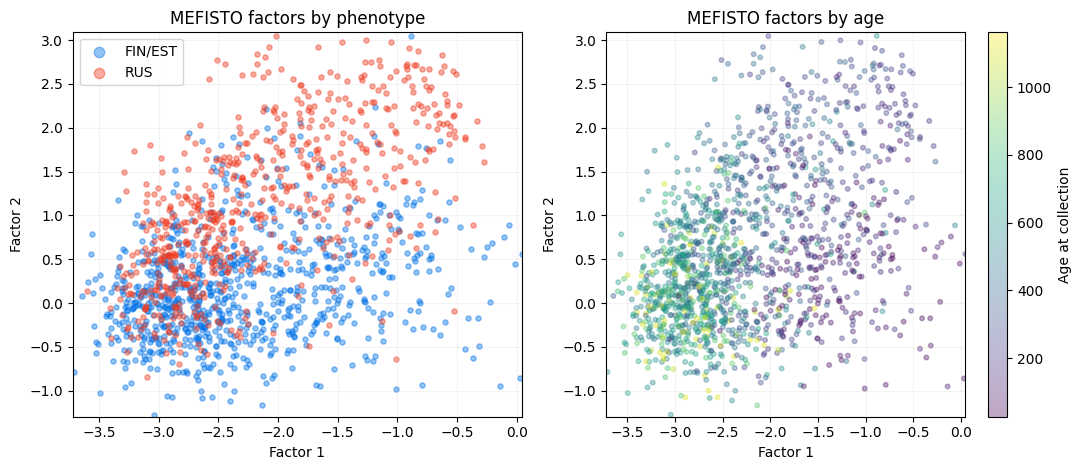

Saved: ../data/figures/20260809_182023/07_mefisto_factor_embedding.png


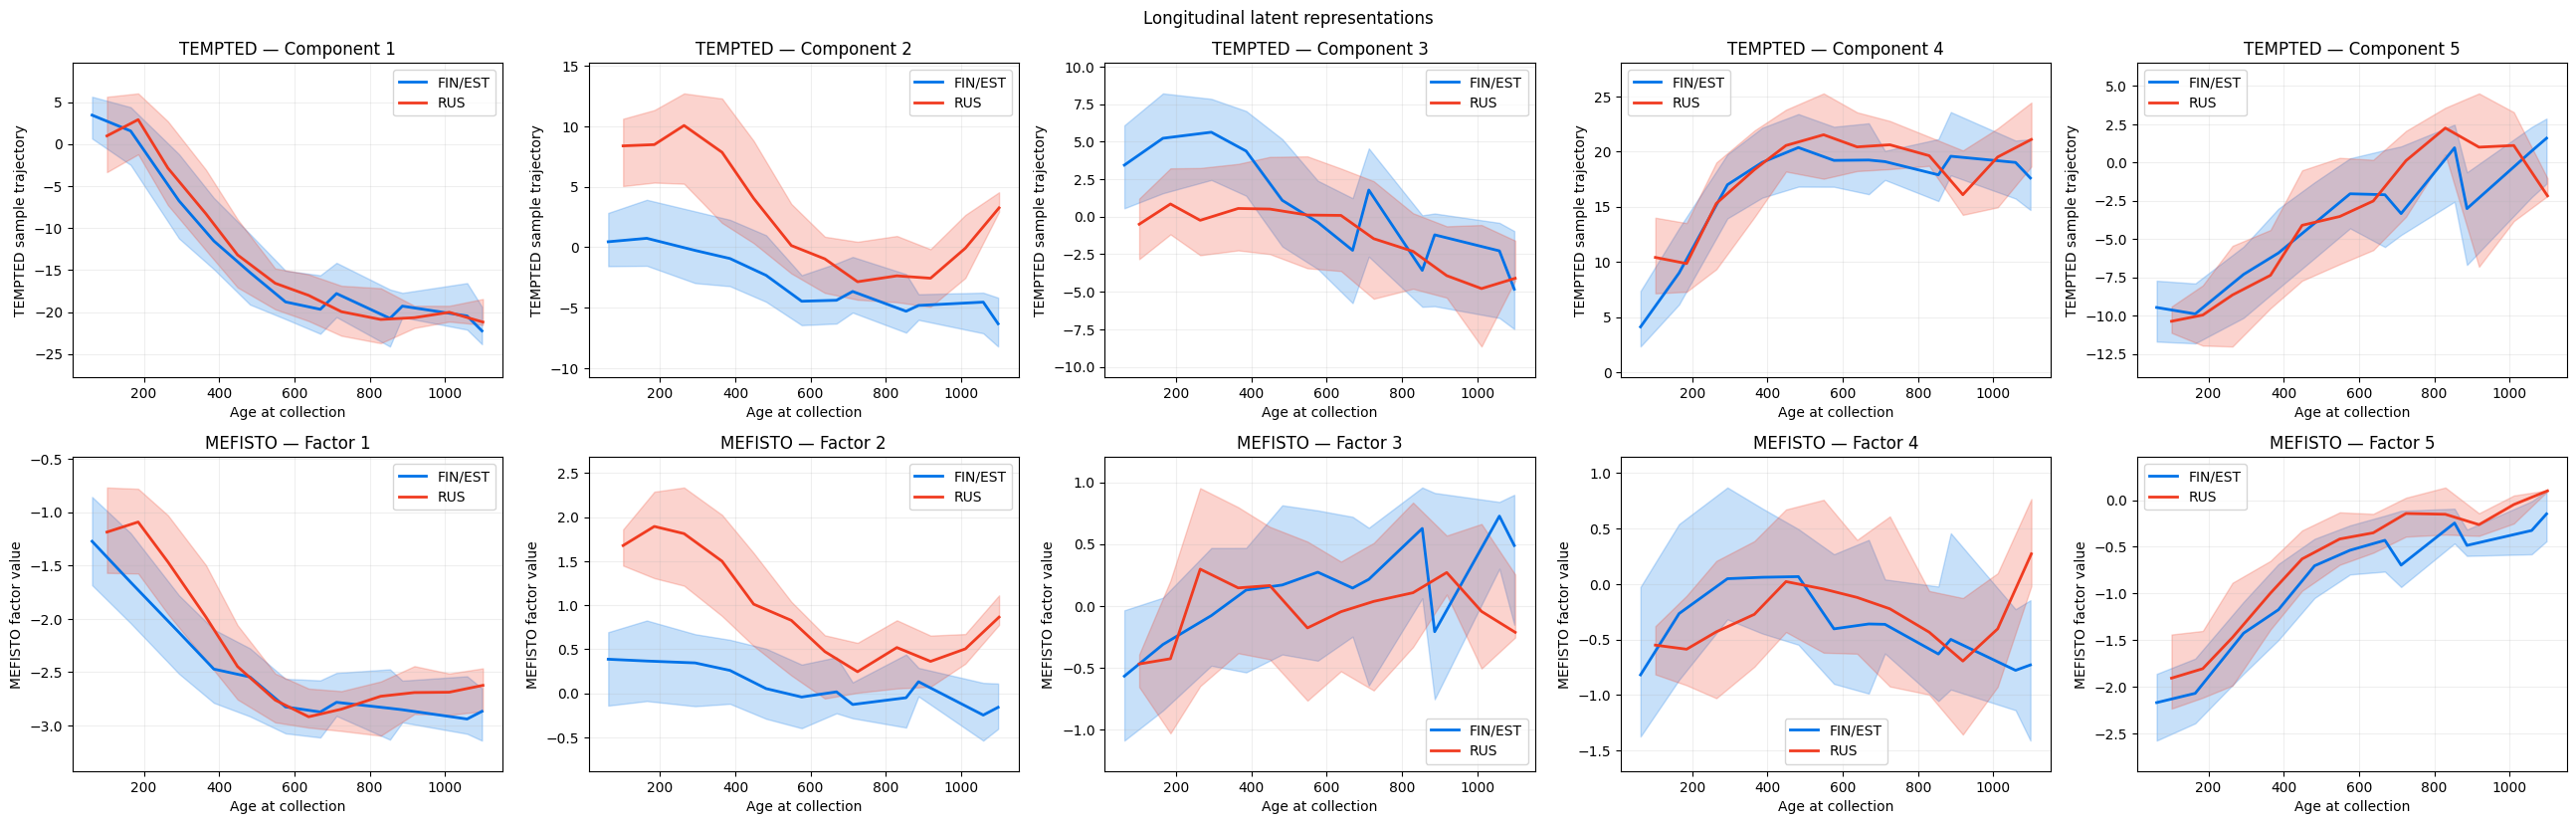

Saved: ../data/figures/20260809_182023/07_latent_trajectory_comparison.png


In [6]:
factor_columns = [column for column in sample_factors.columns if column.startswith("factor_")]

# MEFISTO: fitted factor values, as in the microbiome application in Fig. 3a-b.
mefisto_samples = sample_factors[sample_factors["method"] == "MEFISTO"].copy()
if len(factor_columns) >= 2 and len(mefisto_samples):
    figure, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    for label in GROUP_ORDER:
        rows = mefisto_samples[mefisto_samples["label"] == label]
        if len(rows):
            axes[0].scatter(
                rows[factor_columns[0]], rows[factor_columns[1]],
                s=14, alpha=0.42, label=label,
                color=GROUP_COLORS[label], rasterized=True,
            )
    axes[0].set_xlabel("Factor 1")
    axes[0].set_ylabel("Factor 2")
    axes[0].set_title("MEFISTO factors by phenotype")
    axes[0].legend(markerscale=2)

    scatter = axes[1].scatter(
        mefisto_samples[factor_columns[0]],
        mefisto_samples[factor_columns[1]],
        c=mefisto_samples["time"],
        s=11,
        alpha=0.35,
        rasterized=True,
    )
    axes[1].set_xlabel("Factor 1")
    axes[1].set_ylabel("Factor 2")
    axes[1].set_title("MEFISTO factors by age")
    figure.colorbar(scatter, ax=axes[1], label="Age at collection")

    for axis in axes:
        axis.set_xlim(*robust_limits(mefisto_samples[factor_columns[0]]))
        axis.set_ylim(*robust_limits(mefisto_samples[factor_columns[1]]))
        axis.grid(alpha=0.15)

    figure.tight_layout()
    save_figure(figure, "07_mefisto_factor_embedding.png")

# Longitudinal curves use the sign-aligned values from notebook 06. Free y-scales
# preserve the different model-specific scales.
methods = [method for method in ["TEMPTED", "MEFISTO"] if method in trajectory_summary["method"].unique()]
factor_sets = [
    set(trajectory_summary.loc[trajectory_summary["method"] == method, "factor"])
    for method in methods
]
factors = sorted(set.intersection(*factor_sets), key=lambda x: int(str(x).split("_")[-1]))
if len(factors) != 5:
    raise ValueError(f"Trajectory comparison requires 5 dimensions in both methods; found {factors}")
figure, axes = plt.subplots(len(methods), len(factors), figsize=(5.2 * len(factors), 4.2 * len(methods)), squeeze=False)

for row_index, method in enumerate(methods):
    for column_index, factor in enumerate(factors):
        axis = axes[row_index, column_index]
        rows = trajectory_summary[
            (trajectory_summary["method"] == method) &
            (trajectory_summary["factor"] == factor)
        ]
        for label in GROUP_ORDER:
            group = rows[rows["label"] == label].sort_values("time")
            if len(group):
                axis.plot(
                    group["time"], group["median"], label=label,
                    color=GROUP_COLORS[label], linewidth=2.0,
                )
                axis.fill_between(
                    group["time"], group["lower"], group["upper"],
                    color=GROUP_COLORS[label], alpha=0.22,
                )
        axis.set_title(f"{method} — {display_dimension(method, factor)}")
        axis.set_xlabel("Age at collection")
        axis.set_ylabel(
            "TEMPTED sample trajectory" if method == "TEMPTED"
            else "MEFISTO factor value"
        )
        axis.grid(alpha=0.2)
        if len(rows):
            axis.set_ylim(*robust_limits(np.r_[rows["lower"], rows["upper"]], padding=0.12, lower_quantile=0, upper_quantile=1))
        axis.legend()

figure.suptitle("Longitudinal latent representations")
figure.tight_layout()
save_figure(figure, "07_latent_trajectory_comparison.png")


## Cross-method country separation and genus loading agreement


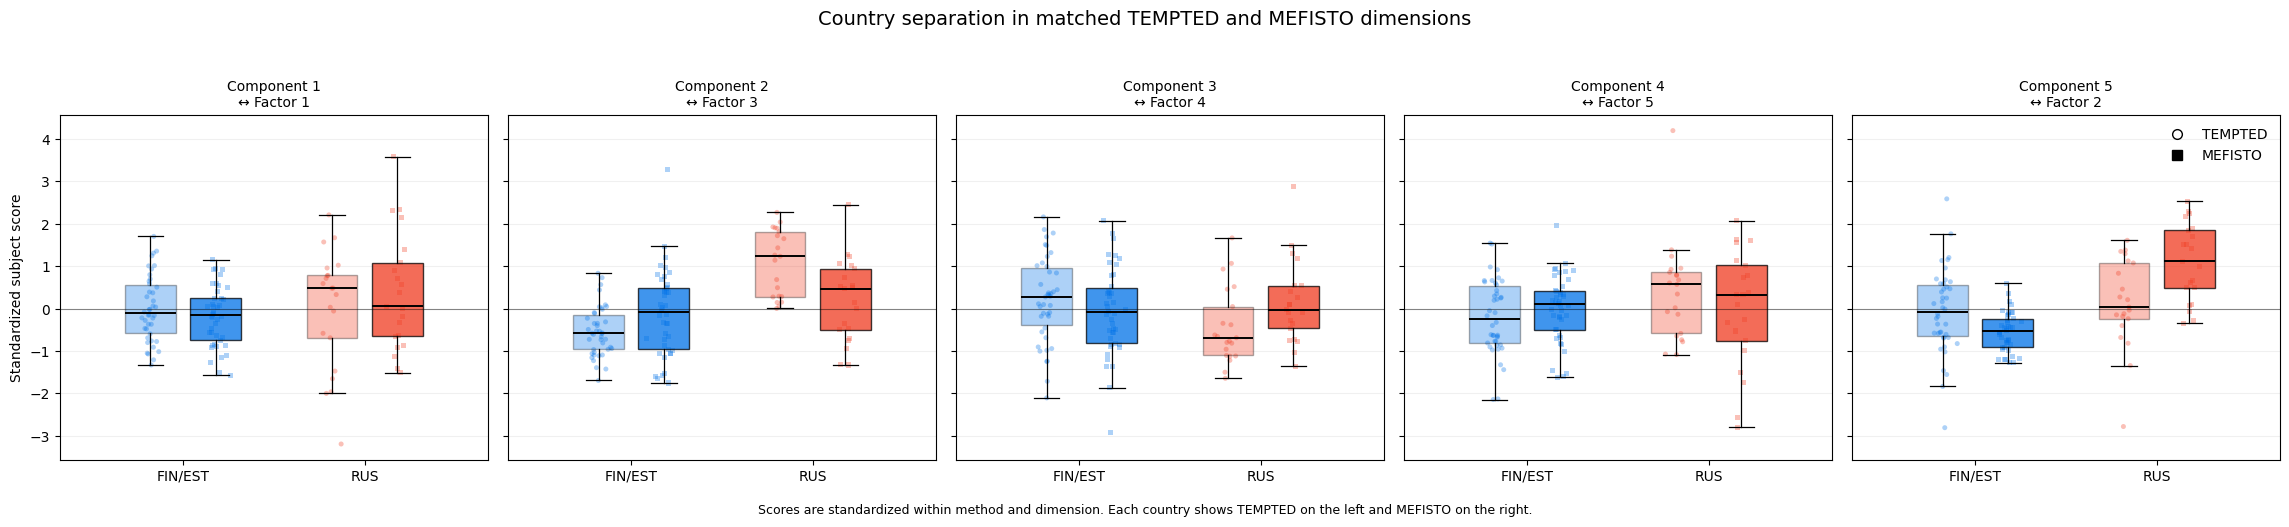

Saved: ../data/figures/20260809_182023/07_subject_country_separation_by_matched_dimension.png


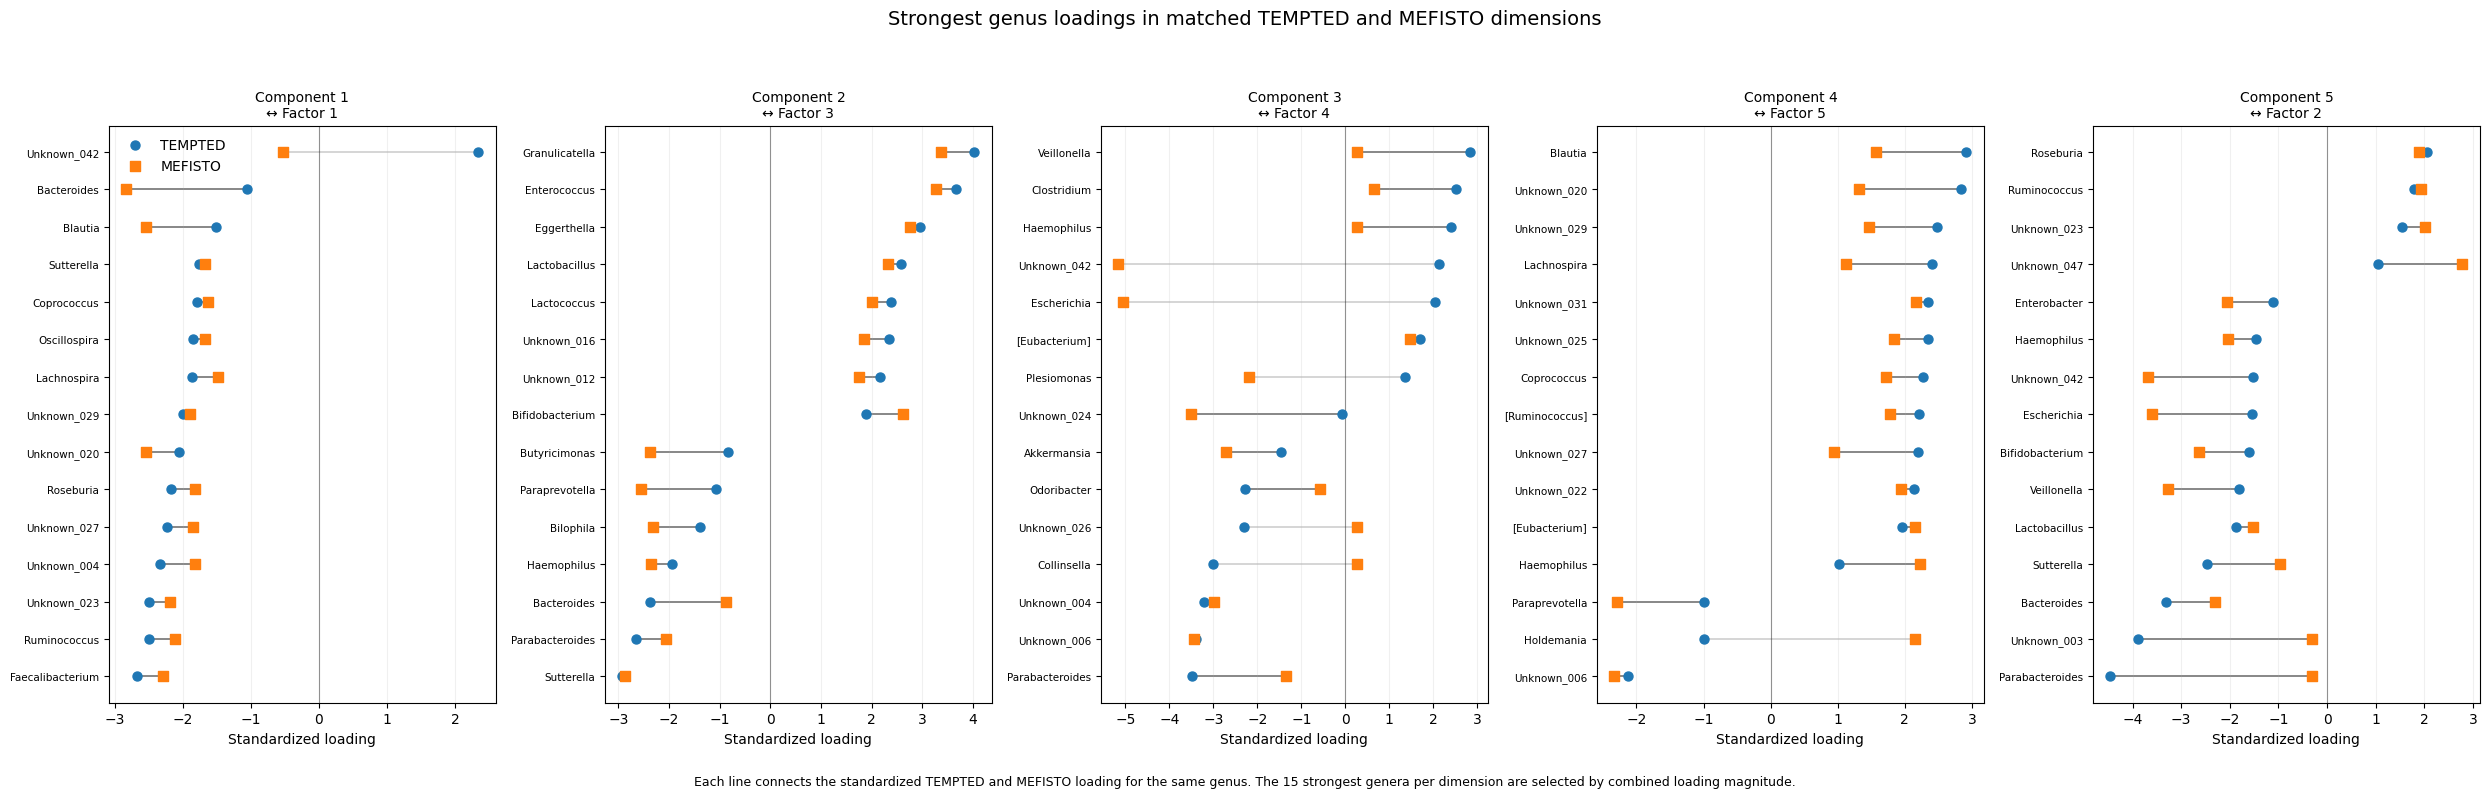

Saved: ../data/figures/20260809_182023/07_top_feature_loading_agreement_by_matched_dimension.png


In [7]:
# ------------------------------------------------------------------
# More interpretable cross-method comparisons
# ------------------------------------------------------------------

def zscore(values):
    values = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(float)

    mean = np.nanmean(values)
    sd = np.nanstd(values)

    if (
        not np.isfinite(sd)
        or sd == 0
    ):
        return values - mean

    return (
        values - mean
    ) / sd


def genus_label(feature):
    text = str(feature)

    if "|" in text:
        parts = text.split("|")
    else:
        parts = text.split(";")

    genus = parts[-1].strip()

    if "__" in genus:
        genus = genus.split("__", 1)[1]

    return genus or "Unclassified"


# ==================================================================
# 1. SUBJECT-LEVEL COMPARISON
# ==================================================================

figure, axes = plt.subplots(
    1,
    5,
    figsize=(23, 5.2),
    sharey=True,
)

rng = np.random.default_rng(
    2026
)

method_offsets = {
    "TEMPTED": -0.18,
    "MEFISTO": 0.18,
}

method_markers = {
    "TEMPTED": "o",
    "MEFISTO": "s",
}


for axis, row in zip(
    axes,
    alignment.itertuples(
        index=False
    ),
):

    tempted_factor = (
        row.tempted_factor
    )

    mefisto_factor = (
        row.mefisto_factor
    )


    tempted = (
        subject_scores[
            subject_scores["method"]
            == "TEMPTED"
        ][
            [
                "subject_id",
                "label",
                tempted_factor,
            ]
        ]
        .copy()
    )

    tempted["score"] = zscore(
        tempted[
            tempted_factor
        ]
    )

    tempted["method"] = (
        "TEMPTED"
    )


    mefisto = (
        subject_scores[
            subject_scores["method"]
            == "MEFISTO"
        ][
            [
                "subject_id",
                "label",
                mefisto_factor,
            ]
        ]
        .copy()
    )

    mefisto["score"] = zscore(
        mefisto[
            mefisto_factor
        ]
    )

    mefisto["method"] = (
        "MEFISTO"
    )


    plot_rows = pd.concat(
        [
            tempted[
                [
                    "subject_id",
                    "label",
                    "score",
                    "method",
                ]
            ],
            mefisto[
                [
                    "subject_id",
                    "label",
                    "score",
                    "method",
                ]
            ],
        ],
        ignore_index=True,
    )


    for country_index, label in enumerate(
        GROUP_ORDER
    ):

        for method in [
            "TEMPTED",
            "MEFISTO",
        ]:

            values = (
                plot_rows[
                    (
                        plot_rows["label"]
                        == label
                    )
                    & (
                        plot_rows["method"]
                        == method
                    )
                ]["score"]
                .dropna()
                .to_numpy(float)
            )

            if len(values) == 0:
                continue


            position = (
                country_index
                + method_offsets[
                    method
                ]
            )


            box = axis.boxplot(
                [values],
                positions=[
                    position
                ],
                widths=0.28,
                patch_artist=True,
                showfliers=False,
                medianprops={
                    "color": "black",
                    "linewidth": 1.4,
                },
                whiskerprops={
                    "linewidth": 0.9,
                },
                capprops={
                    "linewidth": 0.9,
                },
            )


            for patch in box[
                "boxes"
            ]:

                patch.set_facecolor(
                    GROUP_COLORS[
                        label
                    ]
                )

                patch.set_alpha(
                    0.32
                    if method
                    == "TEMPTED"
                    else 0.75
                )

                patch.set_edgecolor(
                    "black"
                )


            jitter = rng.normal(
                0,
                0.025,
                size=len(values),
            )

            axis.scatter(
                np.full(
                    len(values),
                    position,
                )
                + jitter,
                values,
                s=13,
                alpha=0.32,
                color=GROUP_COLORS[
                    label
                ],
                marker=method_markers[
                    method
                ],
                edgecolors="none",
            )


    axis.axhline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.45,
    )

    axis.set_xticks(
        range(
            len(
                GROUP_ORDER
            )
        )
    )

    axis.set_xticklabels(
        GROUP_ORDER
    )

    axis.set_title(
        f"{display_dimension('TEMPTED', tempted_factor)}\n"
        f"↔ {display_dimension('MEFISTO', mefisto_factor)}",
        fontsize=10,
    )

    axis.grid(
        axis="y",
        alpha=0.18,
    )


axes[0].set_ylabel(
    "Standardized subject score"
)


method_legend = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linestyle="none",
        markersize=7,
        markerfacecolor="white",
        label="TEMPTED",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="black",
        linestyle="none",
        markersize=7,
        markerfacecolor="black",
        label="MEFISTO",
    ),
]

axes[-1].legend(
    handles=method_legend,
    loc="best",
    frameon=False,
)


figure.suptitle(
    "Country separation in matched TEMPTED and MEFISTO dimensions",
    fontsize=14,
)

figure.text(
    0.5,
    0.01,
    "Scores are standardized within method and dimension. "
    "Each country shows TEMPTED on the left and MEFISTO on the right.",
    ha="center",
    fontsize=9,
)

figure.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.94,
    ]
)

save_figure(
    figure,
    "07_subject_country_separation_by_matched_dimension.png",
)


# ==================================================================
# 2. FEATURE-LEVEL COMPARISON
# ==================================================================

TOP_FEATURES_PER_DIMENSION = 15


figure, axes = plt.subplots(
    1,
    5,
    figsize=(25, 8),
)


for axis, row in zip(
    axes,
    alignment.itertuples(
        index=False
    ),
):

    tempted_factor = (
        row.tempted_factor
    )

    mefisto_factor = (
        row.mefisto_factor
    )


    left = (
        feature_loadings[
            feature_loadings["method"]
            == "TEMPTED"
        ][
            [
                "feature_id",
                tempted_factor,
            ]
        ]
        .rename(
            columns={
                tempted_factor:
                "tempted"
            }
        )
    )


    mefisto_column = (
        tempted_factor
        if tempted_factor
        in feature_loadings.columns
        else mefisto_factor
    )


    right = (
        feature_loadings[
            feature_loadings["method"]
            == "MEFISTO"
        ][
            [
                "feature_id",
                mefisto_column,
            ]
        ]
        .rename(
            columns={
                mefisto_column:
                "mefisto"
            }
        )
    )


    joined = left.merge(
        right,
        on="feature_id",
        how="inner",
    )


    joined[
        "tempted_z"
    ] = zscore(
        joined[
            "tempted"
        ]
    )

    joined[
        "mefisto_z"
    ] = zscore(
        joined[
            "mefisto"
        ]
    )


    joined[
        "combined_strength"
    ] = np.sqrt(
        (
            joined[
                "tempted_z"
            ]
            ** 2
        )
        +
        (
            joined[
                "mefisto_z"
            ]
            ** 2
        )
    )


    strongest = (
        joined
        .sort_values(
            "combined_strength",
            ascending=False,
        )
        .head(
            TOP_FEATURES_PER_DIMENSION
        )
        .copy()
    )


    strongest[
        "taxon"
    ] = (
        strongest[
            "feature_id"
        ]
        .apply(
            genus_label
        )
    )


    strongest = (
        strongest
        .sort_values(
            "tempted_z"
        )
        .reset_index(
            drop=True
        )
    )


    y = np.arange(
        len(
            strongest
        )
    )


    for index in range(
        len(
            strongest
        )
    ):

        x1 = strongest.loc[
            index,
            "tempted_z",
        ]

        x2 = strongest.loc[
            index,
            "mefisto_z",
        ]


        same_sign = (
            np.sign(
                x1
            )
            == np.sign(
                x2
            )
        )


        axis.plot(
            [
                x1,
                x2,
            ],
            [
                index,
                index,
            ],
            linewidth=1.2,
            alpha=0.55,
            color=(
                "black"
                if same_sign
                else "0.65"
            ),
            zorder=1,
        )


    axis.scatter(
        strongest[
            "tempted_z"
        ],
        y,
        s=42,
        marker="o",
        label="TEMPTED",
        zorder=3,
    )


    axis.scatter(
        strongest[
            "mefisto_z"
        ],
        y,
        s=42,
        marker="s",
        label="MEFISTO",
        zorder=3,
    )


    axis.axvline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.4,
    )


    axis.set_yticks(
        y
    )

    axis.set_yticklabels(
        strongest[
            "taxon"
        ],
        fontsize=7.5,
    )


    axis.set_xlabel(
        "Standardized loading"
    )


    axis.set_title(
        f"{display_dimension('TEMPTED', tempted_factor)}\n"
        f"↔ {display_dimension('MEFISTO', mefisto_factor)}",
        fontsize=10,
    )


    axis.grid(
        axis="x",
        alpha=0.18,
    )


axes[0].legend(
    frameon=False,
    loc="best",
)


figure.suptitle(
    "Strongest genus loadings in matched TEMPTED and MEFISTO dimensions",
    fontsize=14,
)


figure.text(
    0.5,
    0.01,
    "Each line connects the standardized TEMPTED and MEFISTO loading "
    "for the same genus. The 15 strongest genera per dimension are selected "
    "by combined loading magnitude.",
    ha="center",
    fontsize=9,
)


figure.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.94,
    ]
)


save_figure(
    figure,
    "07_top_feature_loading_agreement_by_matched_dimension.png",
)

## Circular Greengenes taxonomy plots

The modeled features are already genus-level Greengenes taxonomic paths, so the hierarchy is constructed directly from kingdom → phylum → class → order → family → genus.

The full and top-30 plots use black cell boundaries and a symmetric nonlinear color normalization so smaller TEMPTED loadings remain visible.


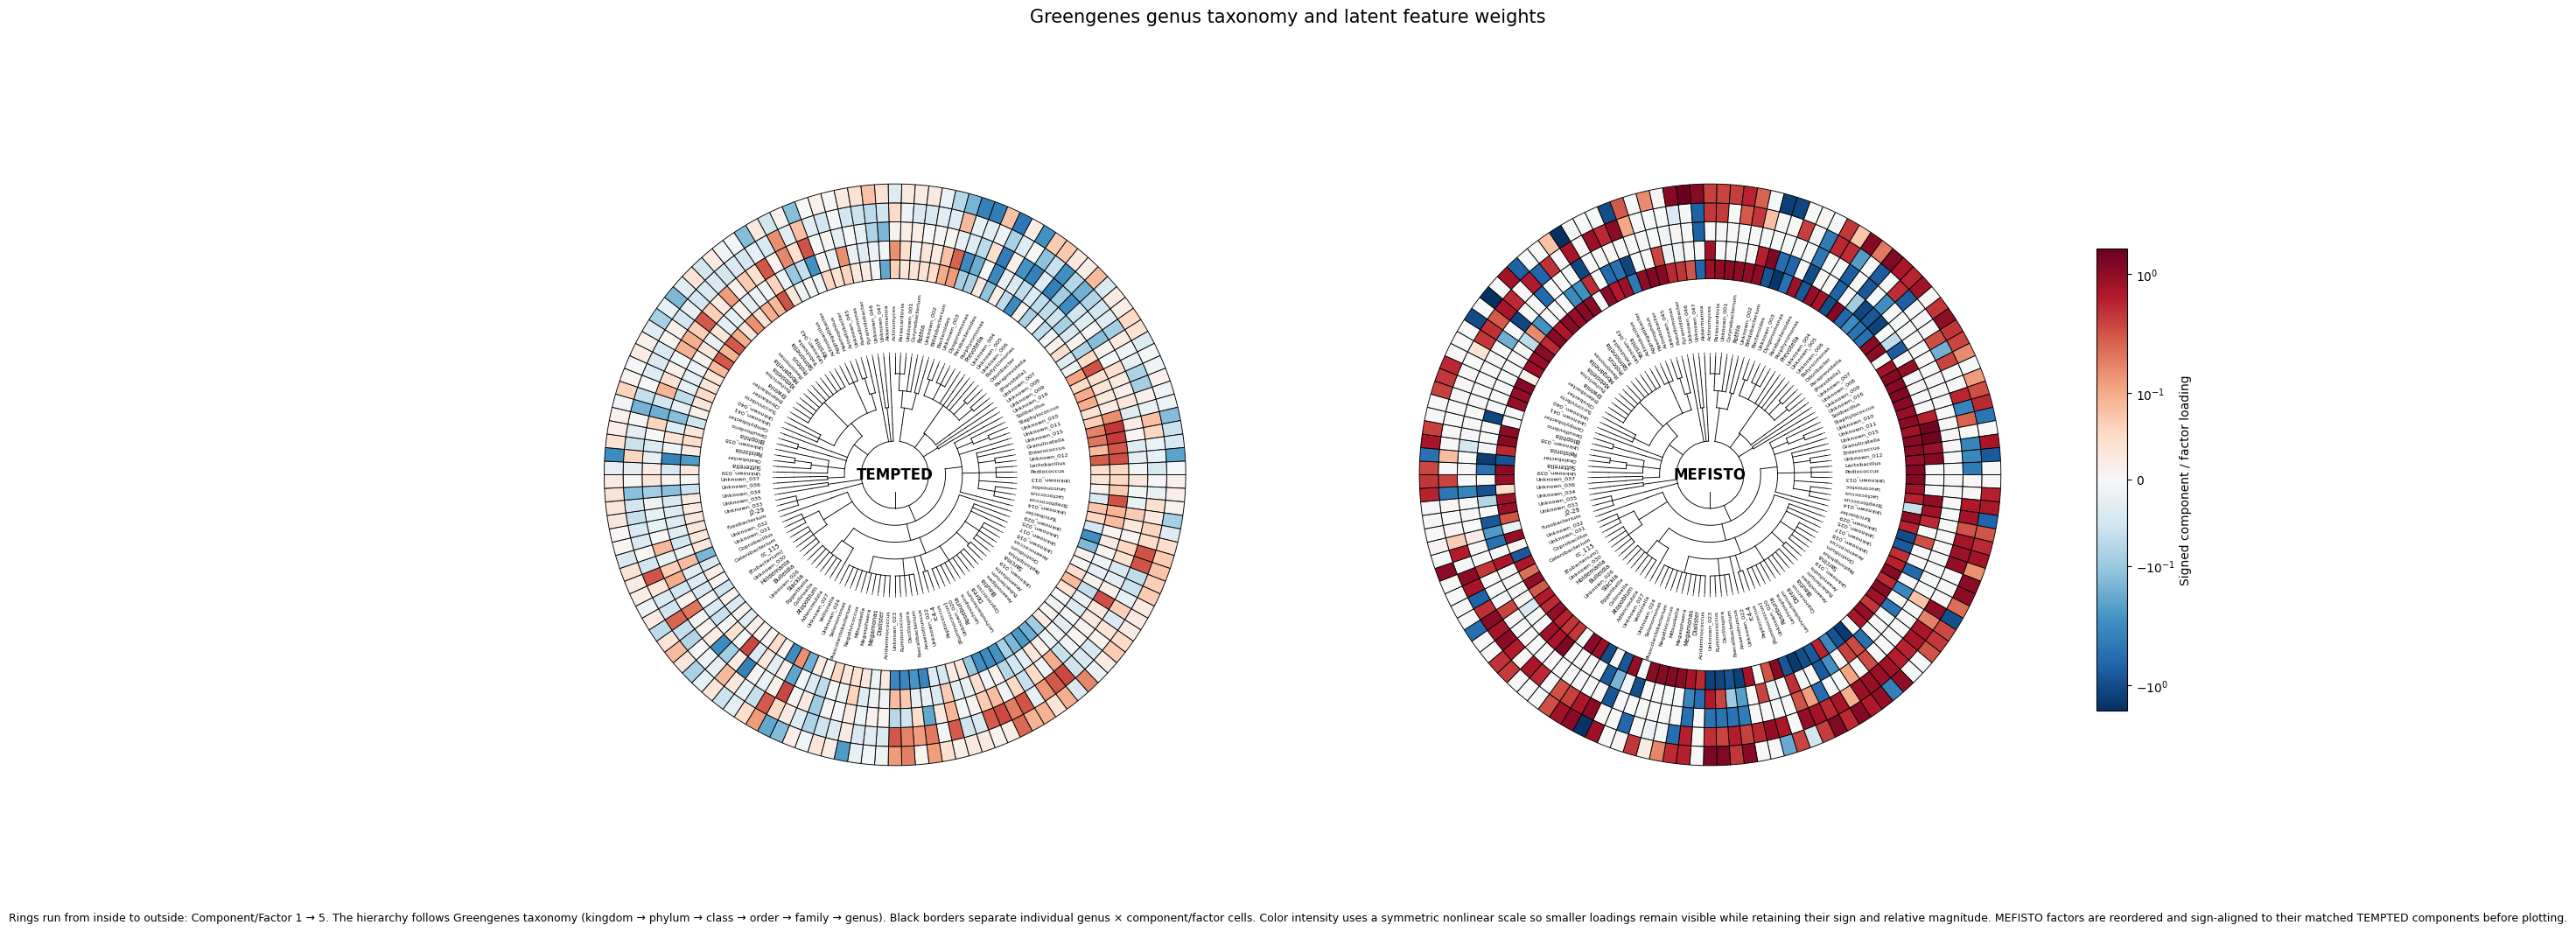

Greengenes taxonomy genera plotted: 134
Ring order: inside → outside = 1 → 5
Color normalization: symmetric log, linear threshold = 0.16158


In [8]:
from matplotlib.colors import SymLogNorm


# ------------------------------------------------------------------
# Greengenes genus taxonomy + aligned TEMPTED / MEFISTO loadings
# ------------------------------------------------------------------

def canonical_taxonomy(text):
    return [
        part.strip()
        for part in str(text).replace(";", "|").split("|")
        if part.strip()
    ]


def rank_label(part):
    return part.split("__", 1)[-1] if "__" in part else part


def get_factor_columns(frame):
    return sorted(
        [
            column
            for column in frame.columns
            if column.startswith("factor_")
            and column.removeprefix("factor_").isdigit()
        ],
        key=lambda column: int(column.split("_")[-1]),
    )


def taxonomy_record(feature_id):
    parts = canonical_taxonomy(feature_id)

    ranks = [
        ("kingdom", "k__"),
        ("phylum", "p__"),
        ("class", "c__"),
        ("order", "o__"),
        ("family", "f__"),
        ("genus", "g__"),
    ]

    record = {"feature_id": feature_id}
    path = []

    for rank, prefix in ranks:
        hit = next(
            (part for part in parts if part.startswith(prefix)),
            None,
        )

        if hit is None:
            hit = prefix + "Unclassified"

        path.append(hit)
        record[rank] = hit

    record["taxonomy_path"] = "|".join(path)

    return record


# ------------------------------------------------------------------
# Keep genus-level features only
# ------------------------------------------------------------------

tree_feature_loadings = feature_loadings.copy()

tree_feature_loadings = tree_feature_loadings[
    tree_feature_loadings["feature_id"]
    .astype(str)
    .str.contains(
        r"(?:^|\|)g__",
        regex=True,
        na=False,
    )
].copy()


# ------------------------------------------------------------------
# Build taxonomy table
# ------------------------------------------------------------------

taxonomy = pd.DataFrame(
    [
        taxonomy_record(feature)
        for feature in sorted(
            tree_feature_loadings["feature_id"]
            .dropna()
            .unique()
        )
    ]
)

tree_feature_loadings = tree_feature_loadings.merge(
    taxonomy,
    on="feature_id",
    how="inner",
)


# ------------------------------------------------------------------
# Confirm five aligned factors/components
# ------------------------------------------------------------------

dimensions_by_method = {
    method: get_factor_columns(
        tree_feature_loadings[
            tree_feature_loadings["method"] == method
        ]
    )
    for method in ["TEMPTED", "MEFISTO"]
}

for method, dimensions in dimensions_by_method.items():
    if len(dimensions) != 5:
        raise ValueError(
            f"Expected five {method} dimensions for the taxonomy plot; "
            f"found {dimensions}"
        )


expected_dimensions = [
    "factor_1",
    "factor_2",
    "factor_3",
    "factor_4",
    "factor_5",
]

for method, dimensions in dimensions_by_method.items():
    if dimensions != expected_dimensions:
        raise ValueError(
            f"{method} factor order is not aligned as expected: "
            f"{dimensions}"
        )


# ------------------------------------------------------------------
# Keep the same genera in both panels
# ------------------------------------------------------------------

method_features = {
    method: set(
        tree_feature_loadings.loc[
            tree_feature_loadings["method"] == method,
            "feature_id",
        ]
    )
    for method in ["TEMPTED", "MEFISTO"]
}

shared_features = sorted(
    method_features["TEMPTED"]
    & method_features["MEFISTO"]
)

if not shared_features:
    raise ValueError(
        "No shared genus features are available "
        "for the Greengenes taxonomy plot."
    )


selected = tree_feature_loadings[
    tree_feature_loadings["feature_id"].isin(shared_features)
].copy()


# ------------------------------------------------------------------
# Taxonomic paths
# ------------------------------------------------------------------

paths = {
    row.feature_id: tuple(
        canonical_taxonomy(row.taxonomy_path)
    )
    for row in taxonomy[
        taxonomy["feature_id"].isin(shared_features)
    ].itertuples(index=False)
}


# ------------------------------------------------------------------
# Parent-child hierarchy
# ------------------------------------------------------------------

children = {
    (): set()
}

for path in paths.values():
    parent = ()

    for depth in range(1, len(path) + 1):
        node = path[:depth]

        children.setdefault(
            parent,
            set(),
        ).add(node)

        children.setdefault(
            node,
            set(),
        )

        parent = node


# ------------------------------------------------------------------
# Taxonomic order around circle
# ------------------------------------------------------------------

tip_nodes = sorted(
    set(paths.values())
)

if not tip_nodes:
    raise ValueError(
        "No terminal genus nodes were created "
        "for the taxonomy plot."
    )


tip_angles = {
    node: (
        2
        * np.pi
        * index
        / len(tip_nodes)
    )
    for index, node in enumerate(tip_nodes)
}


def descendant_tip_angles(node):
    if node in tip_angles:
        return [
            tip_angles[node]
        ]

    values = []

    for child in sorted(
        children.get(
            node,
            [],
        )
    ):
        values.extend(
            descendant_tip_angles(
                child
            )
        )

    return values


# ------------------------------------------------------------------
# Internal-node positions
# ------------------------------------------------------------------

node_angles = {}

for node in children:
    angles = descendant_tip_angles(
        node
    )

    if angles:
        node_angles[node] = (
            np.angle(
                np.mean(
                    np.exp(
                        1j
                        * np.asarray(
                            angles
                        )
                    )
                )
            )
            % (
                2
                * np.pi
            )
        )


max_depth = max(
    len(node)
    for node in children
)

node_radii = {
    node: (
        0.08
        + 0.48
        * len(node)
        / max_depth
    )
    for node in children
}


# ------------------------------------------------------------------
# Shared loading color scale
#
# SymLogNorm expands small-to-moderate loading differences so the
# lighter TEMPTED weights remain visible, while retaining:
#
#   - one common scale across both methods
#   - sign
#   - zero at the neutral center
#   - the original loading values
# ------------------------------------------------------------------

all_dimensions = expected_dimensions

values = selected[
    all_dimensions
].to_numpy(float)

scale_limit = np.nanmax(
    np.abs(values)
)

if (
    not np.isfinite(scale_limit)
    or scale_limit == 0
):
    scale_limit = 1.0


color_norm = SymLogNorm(
    linthresh=scale_limit * 0.08,
    linscale=1.5,
    vmin=-scale_limit,
    vmax=scale_limit,
    base=10,
)

color_map = plt.get_cmap(
    "RdBu_r"
)


# ------------------------------------------------------------------
# Geometry
#
# The taxonomy labels occupy a dedicated inner zone.
# There is a white buffer before the loading rings begin.
# ------------------------------------------------------------------

tree_tip_radius = 0.58

label_radius = 0.64

label_outer_limit = 0.82

ring_inner = 0.93

ring_width = 0.090

ring_gap = 0.0

angular_width = (
    2
    * np.pi
    / len(tip_nodes)
)

outer_ring_radius = (
    ring_inner
    + len(all_dimensions)
    * ring_width
)


# ------------------------------------------------------------------
# Draw taxonomy branches
# ------------------------------------------------------------------

def draw_branches(axis):

    for (
        parent,
        child_nodes,
    ) in children.items():

        if (
            not child_nodes
            or parent not in node_angles
        ):
            continue

        parent_angle = node_angles[
            parent
        ]

        parent_radius = node_radii[
            parent
        ]

        child_nodes = sorted(
            child_nodes
        )

        child_angles = np.asarray(
            [
                node_angles[
                    child
                ]
                for child
                in child_nodes
            ]
        )

        relative = np.angle(
            np.exp(
                1j
                * (
                    child_angles
                    - parent_angle
                )
            )
        )

        unwrapped = (
            parent_angle
            + relative
        )

        if len(unwrapped) > 1:
            arc = np.linspace(
                unwrapped.min(),
                unwrapped.max(),
                30,
            )

            axis.plot(
                arc,
                np.full_like(
                    arc,
                    parent_radius,
                ),
                color="black",
                linewidth=0.65,
                zorder=3,
            )

        for (
            child,
            child_angle,
        ) in zip(
            child_nodes,
            unwrapped,
        ):
            axis.plot(
                [
                    child_angle,
                    child_angle,
                ],
                [
                    parent_radius,
                    node_radii[
                        child
                    ],
                ],
                color="black",
                linewidth=0.65,
                zorder=3,
            )


# ------------------------------------------------------------------
# Genus labels
# ------------------------------------------------------------------

def genus_font_size(text):

    length = len(
        str(text)
    )

    if length <= 10:
        return 5.0

    if length <= 16:
        return 4.6

    if length <= 22:
        return 4.2

    if length <= 28:
        return 3.8

    return 3.4


def draw_tip_label(
    axis,
    angle,
    radius,
    text,
):

    degrees = (
        np.degrees(
            angle
        )
        % 360
    )

    rotation = (
        90
        - degrees
    )

    horizontal_alignment = (
        "left"
    )

    if (
        90
        < degrees
        < 270
    ):
        rotation += 180

        horizontal_alignment = (
            "right"
        )

    axis.text(
        angle,
        radius,
        text,

        rotation=rotation,
        rotation_mode="anchor",

        ha=horizontal_alignment,
        va="center",

        fontsize=genus_font_size(
            text
        ),

        color="black",
        clip_on=True,
        zorder=5,
    )


feature_for_tip = {
    path: feature
    for feature, path
    in paths.items()
    if feature
    in shared_features
}


# ------------------------------------------------------------------
# Draw one method
# ------------------------------------------------------------------

def draw_method(
    axis,
    method,
):

    rows = (
        selected[
            selected["method"]
            == method
        ]
        .drop_duplicates(
            "feature_id"
        )
        .set_index(
            "feature_id"
        )
    )

    dimensions = dimensions_by_method[
        method
    ]


    # Polar orientation.

    axis.set_theta_direction(
        -1
    )

    axis.set_theta_offset(
        np.pi / 2
    )

    axis.set_axis_off()


    # Everything inside the heatmap remains white.

    axis.set_facecolor(
        "white"
    )

    axis.patch.set_facecolor(
        "white"
    )

    axis.patch.set_alpha(
        1.0
    )


    axis.set_ylim(
        0,
        outer_ring_radius
        + 0.18,
    )


    # --------------------------------------------------------------
    # Taxonomy tree
    # --------------------------------------------------------------

    draw_branches(
        axis
    )


    # --------------------------------------------------------------
    # Terminal branches + genus labels
    # --------------------------------------------------------------

    for tip in tip_nodes:

        angle = tip_angles[
            tip
        ]

        genus = (
            rank_label(
                tip[-1]
            )
            or "Unclassified"
        )


        axis.plot(
            [
                angle,
                angle,
            ],
            [
                node_radii[
                    tip
                ],
                tree_tip_radius,
            ],
            color="black",
            linewidth=0.45,
            zorder=4,
        )


        draw_tip_label(
            axis,
            angle,
            label_radius,
            genus,
        )


    # --------------------------------------------------------------
    # Loading rings
    #
    # Black borders separate every genus × component/factor cell.
    # SymLogNorm makes smaller signed weights easier to distinguish.
    # --------------------------------------------------------------

    for (
        index,
        factor,
    ) in enumerate(
        dimensions
    ):

        bottom = (
            ring_inner
            + index
            * ring_width
        )

        for tip in tip_nodes:

            feature = feature_for_tip[
                tip
            ]

            if (
                feature
                in rows.index
            ):
                value = float(
                    rows.loc[
                        feature,
                        factor,
                    ]
                )

            else:
                value = np.nan


            if np.isfinite(
                value
            ):
                face = color_map(
                    color_norm(
                        value
                    )
                )

            else:
                face = (
                    0.93,
                    0.93,
                    0.93,
                    1.0,
                )


            axis.bar(
                tip_angles[
                    tip
                ],

                ring_width,

                width=angular_width,

                bottom=bottom,

                color=face,

                edgecolor="black",

                linewidth=0.65,

                align="center",

                zorder=2,
            )


    # --------------------------------------------------------------
    # Method name
    # --------------------------------------------------------------

    axis.text(
        0,
        0,
        method,

        ha="center",
        va="center",

        fontsize=12,
        fontweight="bold",

        color="black",

        zorder=6,
    )


# ------------------------------------------------------------------
# Draw both methods
# ------------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    2,

    figsize=(
        22,
        11,
    ),

    subplot_kw={
        "projection":
        "polar"
    },
)


figure.patch.set_facecolor(
    "white"
)


for (
    axis,
    method,
) in zip(
    axes,
    [
        "TEMPTED",
        "MEFISTO",
    ],
):

    draw_method(
        axis,
        method,
    )


# ------------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------------

scalar = plt.cm.ScalarMappable(
    norm=color_norm,
    cmap=color_map,
)

scalar.set_array(
    []
)


legend_axis = figure.add_axes(
    [
        0.92,
        0.25,
        0.016,
        0.48,
    ]
)

legend_axis.set_facecolor(
    "white"
)


colorbar = figure.colorbar(
    scalar,
    cax=legend_axis,
)

colorbar.set_label(
    "Signed component / factor loading"
)


# ------------------------------------------------------------------
# Titles
# ------------------------------------------------------------------

figure.suptitle(
    "Greengenes genus taxonomy and latent feature weights",
    fontsize=15,
)


figure.text(
    0.5,
    0.035,

    "Rings run from inside to outside: Component/Factor 1 → 5. "
    "The hierarchy follows Greengenes taxonomy "
    "(kingdom → phylum → class → order → family → genus). "
    "Black borders separate individual genus × component/factor cells. "
    "Color intensity uses a symmetric nonlinear scale so smaller loadings "
    "remain visible while retaining their sign and relative magnitude. "
    "MEFISTO factors are reordered and sign-aligned to their matched "
    "TEMPTED components before plotting.",

    ha="center",
    va="center",

    fontsize=9,
)


figure.subplots_adjust(
    top=0.90,
    bottom=0.09,
    wspace=0.24,
    right=0.89,
)


# ------------------------------------------------------------------
# Save / display
# ------------------------------------------------------------------

figure.savefig(
    output
    / "07_circular_greengenes_factor_weights.png",

    dpi=220,

    facecolor="white",

    edgecolor="none",
)


plt.show()

plt.close(
    figure
)


# ------------------------------------------------------------------
# Save plotted mapping
# ------------------------------------------------------------------

selected[
    [
        "method",
        "feature_id",
        "kingdom",
        "phylum",
        "class",
        "order",
        "family",
        "genus",
        *all_dimensions,
    ]
].to_csv(
    plot_data_folder
    / "07_circular_greengenes_feature_mapping.csv",

    index=False,
)


print(
    "Greengenes taxonomy genera plotted:",
    len(
        shared_features
    ),
)

print(
    "Ring order: inside → outside = 1 → 5"
)

print(
    "Color normalization: symmetric log, "
    f"linear threshold = {scale_limit * 0.08:.5g}"
)

Top taxa selected: 30


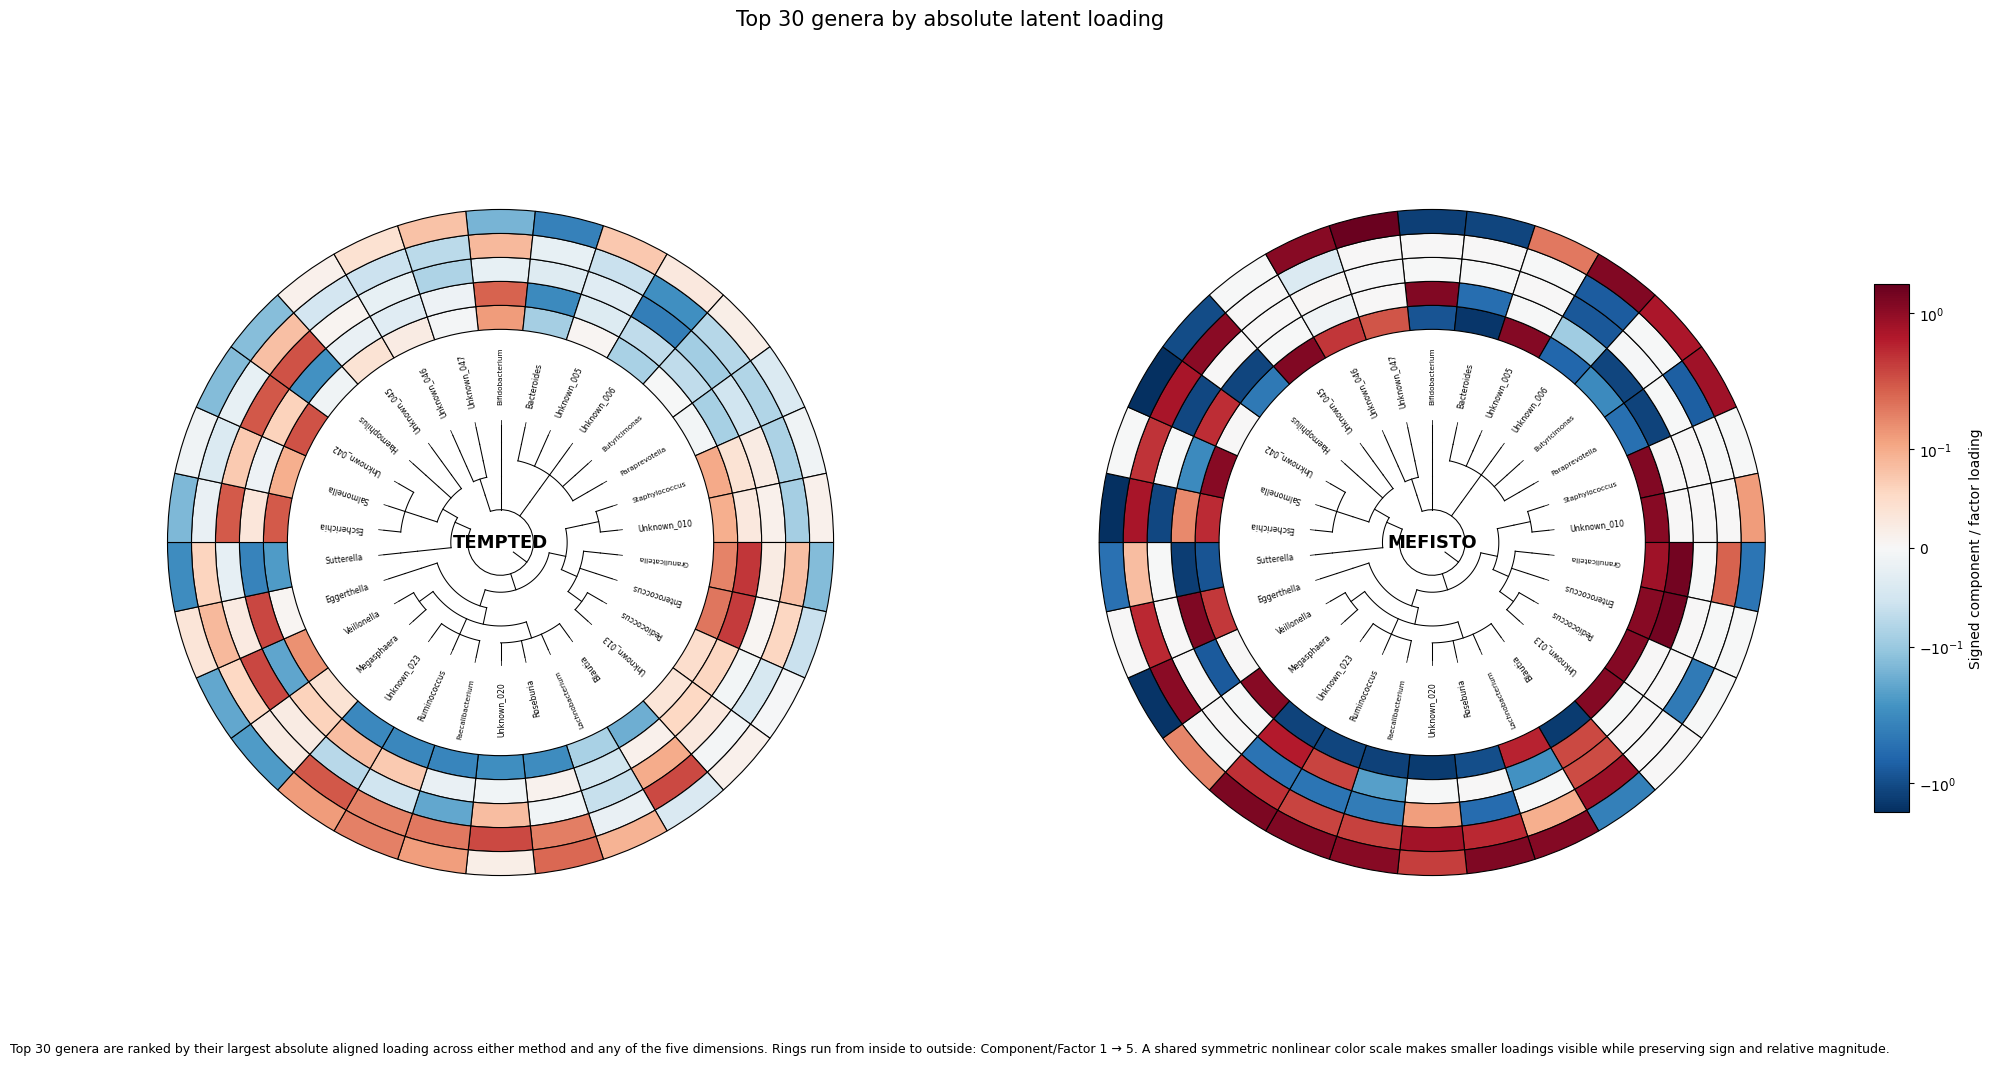

Top-30 taxonomy genera plotted: 30
Ring order: inside → outside = 1 → 5
Color normalization: symmetric log, linear threshold = 0.16158


,rank,feature_id,importance
0,1,k__Bacteria|p__Proteobacteria|c__Gammaproteoba...,2.019762
1,2,k__Bacteria|p__Proteobacteria|c__Gammaproteoba...,1.974515
2,3,k__Bacteria|p__Tenericutes|c__Mollicutes|o__RF...,1.850789
3,4,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,1.775465
4,5,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,1.719894
5,6,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,1.634095
6,7,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,1.585876
7,8,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,1.505381
8,9,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,1.503256
9,10,k__Bacteria|p__Proteobacteria|c__Betaproteobac...,1.427405


In [9]:
from matplotlib.colors import SymLogNorm

# ------------------------------------------------------------------
# Top-30 genus circular Greengenes taxonomy plot
#
# Select the 30 genera with the strongest absolute loading across
# either TEMPTED or MEFISTO and across any of the five aligned
# components/factors.
#
# Uses a symmetric nonlinear color scale so smaller TEMPTED
# loadings remain visible instead of appearing nearly white.
# ------------------------------------------------------------------

TOP_N_TAXA = 30


# ------------------------------------------------------------------
# Rank genera by strongest absolute loading
# ------------------------------------------------------------------

taxon_importance = (
    selected
    .groupby("feature_id")[all_dimensions]
    .agg(
        lambda column: np.nanmax(
            np.abs(column.to_numpy(float))
        )
    )
)

taxon_importance["importance"] = (
    taxon_importance[all_dimensions]
    .max(axis=1)
)

top_features = (
    taxon_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .head(TOP_N_TAXA)
    .index
    .tolist()
)

top_selected = selected[
    selected["feature_id"].isin(top_features)
].copy()

print(
    "Top taxa selected:",
    len(top_features),
)


# ------------------------------------------------------------------
# Nonlinear loading color scale
#
# Use the SAME overall scale limit as the full plot, but apply
# SymLogNorm so smaller weights receive more visible color.
# ------------------------------------------------------------------

top_color_norm = SymLogNorm(
    linthresh=scale_limit * 0.08,
    linscale=1.5,
    vmin=-scale_limit,
    vmax=scale_limit,
    base=10,
)

top_color_map = plt.get_cmap(
    "RdBu_r"
)


# ------------------------------------------------------------------
# Build taxonomy paths for only the selected genera
# ------------------------------------------------------------------

top_paths = {
    row.feature_id: tuple(
        canonical_taxonomy(
            row.taxonomy_path
        )
    )
    for row in taxonomy[
        taxonomy["feature_id"].isin(top_features)
    ].itertuples(index=False)
}


# ------------------------------------------------------------------
# Build reduced parent-child hierarchy
# ------------------------------------------------------------------

top_children = {
    (): set()
}

for path in top_paths.values():

    parent = ()

    for depth in range(
        1,
        len(path) + 1,
    ):

        node = path[:depth]

        top_children.setdefault(
            parent,
            set(),
        ).add(node)

        top_children.setdefault(
            node,
            set(),
        )

        parent = node


# ------------------------------------------------------------------
# Taxonomic ordering
# ------------------------------------------------------------------

top_tip_nodes = sorted(
    set(top_paths.values())
)

if not top_tip_nodes:
    raise ValueError(
        "No taxa were available for the top-30 taxonomy plot."
    )


top_tip_angles = {
    node: (
        2
        * np.pi
        * index
        / len(top_tip_nodes)
    )
    for index, node
    in enumerate(top_tip_nodes)
}


# ------------------------------------------------------------------
# Internal-node positions
# ------------------------------------------------------------------

def top_descendant_tip_angles(node):

    if node in top_tip_angles:
        return [
            top_tip_angles[node]
        ]

    values = []

    for child in sorted(
        top_children.get(
            node,
            [],
        )
    ):

        values.extend(
            top_descendant_tip_angles(
                child
            )
        )

    return values


top_node_angles = {}

for node in top_children:

    angles = top_descendant_tip_angles(
        node
    )

    if angles:

        top_node_angles[node] = (
            np.angle(
                np.mean(
                    np.exp(
                        1j
                        * np.asarray(angles)
                    )
                )
            )
            % (
                2
                * np.pi
            )
        )


top_max_depth = max(
    len(node)
    for node
    in top_children
)


# Compress taxonomy toward center.

top_node_radii = {
    node: (
        0.06
        + 0.38
        * len(node)
        / top_max_depth
    )
    for node
    in top_children
}


# ------------------------------------------------------------------
# Geometry
# ------------------------------------------------------------------

top_tree_tip_radius = 0.46

top_label_radius = 0.52

# Preserve current ring position.
top_ring_inner = 0.8

top_ring_width = 0.090

top_angular_width = (
    2
    * np.pi
    / len(top_tip_nodes)
)

top_outer_ring_radius = (
    top_ring_inner
    + len(all_dimensions)
    * top_ring_width
)


top_feature_for_tip = {
    path: feature
    for feature, path
    in top_paths.items()
}


# ------------------------------------------------------------------
# Draw reduced taxonomy branches
# ------------------------------------------------------------------

def draw_top_branches(axis):

    for (
        parent,
        child_nodes,
    ) in top_children.items():

        if (
            not child_nodes
            or parent not in top_node_angles
        ):
            continue

        parent_angle = (
            top_node_angles[
                parent
            ]
        )

        parent_radius = (
            top_node_radii[
                parent
            ]
        )

        child_nodes = sorted(
            child_nodes
        )

        child_angles = np.asarray(
            [
                top_node_angles[
                    child
                ]
                for child
                in child_nodes
            ]
        )

        # Keep clades near 0 / 2π local.

        relative = np.angle(
            np.exp(
                1j
                * (
                    child_angles
                    - parent_angle
                )
            )
        )

        unwrapped = (
            parent_angle
            + relative
        )

        if len(unwrapped) > 1:

            arc = np.linspace(
                unwrapped.min(),
                unwrapped.max(),
                30,
            )

            axis.plot(
                arc,
                np.full_like(
                    arc,
                    parent_radius,
                ),
                color="black",
                linewidth=0.75,
                zorder=3,
            )

        for (
            child,
            child_angle,
        ) in zip(
            child_nodes,
            unwrapped,
        ):

            axis.plot(
                [
                    child_angle,
                    child_angle,
                ],
                [
                    parent_radius,
                    top_node_radii[
                        child
                    ],
                ],
                color="black",
                linewidth=0.75,
                zorder=3,
            )


# ------------------------------------------------------------------
# Label sizing
# ------------------------------------------------------------------

def top_genus_font_size(text):

    length = len(
        str(text)
    )

    if length <= 8:
        return 6.0

    if length <= 12:
        return 5.6

    if length <= 16:
        return 5.2

    if length <= 20:
        return 4.8

    if length <= 24:
        return 4.4

    if length <= 28:
        return 4.0

    return 3.6


def draw_top_tip_label(
    axis,
    angle,
    radius,
    text,
):

    degrees = (
        np.degrees(
            angle
        )
        % 360
    )

    rotation = (
        90
        - degrees
    )

    horizontal_alignment = (
        "left"
    )

    if (
        90
        < degrees
        < 270
    ):

        rotation += 180

        horizontal_alignment = (
            "right"
        )

    axis.text(
        angle,
        radius,
        text,
        rotation=rotation,
        rotation_mode="anchor",
        ha=horizontal_alignment,
        va="center",
        fontsize=top_genus_font_size(
            text
        ),
        color="black",
        clip_on=True,
        zorder=5,
    )


# ------------------------------------------------------------------
# Draw one method
# ------------------------------------------------------------------

def draw_top_method(
    axis,
    method,
):

    rows = (
        top_selected[
            top_selected["method"]
            == method
        ]
        .drop_duplicates(
            "feature_id"
        )
        .set_index(
            "feature_id"
        )
    )

    dimensions = (
        dimensions_by_method[
            method
        ]
    )


    # Polar orientation.

    axis.set_theta_direction(
        -1
    )

    axis.set_theta_offset(
        np.pi
        / 2
    )

    axis.set_axis_off()


    # White center / taxonomy area.

    axis.set_facecolor(
        "white"
    )

    axis.patch.set_facecolor(
        "white"
    )

    axis.patch.set_alpha(
        1.0
    )


    axis.set_ylim(
        0,
        top_outer_ring_radius
        + 0.16,
    )


    # --------------------------------------------------------------
    # Taxonomy tree
    # --------------------------------------------------------------

    draw_top_branches(
        axis
    )


    # --------------------------------------------------------------
    # Terminal branches + labels
    # --------------------------------------------------------------

    for tip in top_tip_nodes:

        angle = (
            top_tip_angles[
                tip
            ]
        )

        genus = (
            rank_label(
                tip[-1]
            )
            or "Unclassified"
        )

        axis.plot(
            [
                angle,
                angle,
            ],
            [
                top_node_radii[
                    tip
                ],
                top_tree_tip_radius,
            ],
            color="black",
            linewidth=0.55,
            zorder=4,
        )

        draw_top_tip_label(
            axis,
            angle,
            top_label_radius,
            genus,
        )


    # --------------------------------------------------------------
    # Five loading rings
    #
    # SymLogNorm increases visibility of smaller weights.
    # Black borders separate every individual cell.
    # --------------------------------------------------------------

    for (
        index,
        factor,
    ) in enumerate(
        dimensions
    ):

        bottom = (
            top_ring_inner
            + index
            * top_ring_width
        )

        for tip in top_tip_nodes:

            feature = (
                top_feature_for_tip[
                    tip
                ]
            )

            if (
                feature
                in rows.index
            ):

                value = float(
                    rows.loc[
                        feature,
                        factor,
                    ]
                )

            else:

                value = np.nan


            if np.isfinite(
                value
            ):

                face = top_color_map(
                    top_color_norm(
                        value
                    )
                )

            else:

                face = (
                    0.93,
                    0.93,
                    0.93,
                    1.0,
                )


            axis.bar(
                top_tip_angles[
                    tip
                ],
                top_ring_width,
                width=top_angular_width,
                bottom=bottom,
                color=face,
                edgecolor="black",
                linewidth=0.80,
                align="center",
                zorder=2,
            )


    # --------------------------------------------------------------
    # Method name
    # --------------------------------------------------------------

    axis.text(
        0,
        0,
        method,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="black",
        zorder=6,
    )


# ------------------------------------------------------------------
# Draw both methods
# ------------------------------------------------------------------

figure_top30, axes_top30 = plt.subplots(
    1,
    2,
    figsize=(
        22,
        11,
    ),
    subplot_kw={
        "projection":
        "polar"
    },
)


figure_top30.patch.set_facecolor(
    "white"
)


for (
    axis,
    method,
) in zip(
    axes_top30,
    [
        "TEMPTED",
        "MEFISTO",
    ],
):

    draw_top_method(
        axis,
        method,
    )


# ------------------------------------------------------------------
# Shared nonlinear colorbar
# ------------------------------------------------------------------

top_scalar = plt.cm.ScalarMappable(
    norm=top_color_norm,
    cmap=top_color_map,
)

top_scalar.set_array(
    []
)


top_legend_axis = (
    figure_top30.add_axes(
        [
            0.92,
            0.25,
            0.016,
            0.48,
        ]
    )
)

top_legend_axis.set_facecolor(
    "white"
)


top_colorbar = (
    figure_top30.colorbar(
        top_scalar,
        cax=top_legend_axis,
    )
)

top_colorbar.set_label(
    "Signed component / factor loading"
)


# ------------------------------------------------------------------
# Titles / explanation
# ------------------------------------------------------------------

figure_top30.suptitle(
    "Top 30 genera by absolute latent loading",
    fontsize=15,
)


figure_top30.text(
    0.5,
    0.035,

    "Top 30 genera are ranked by their largest absolute aligned loading "
    "across either method and any of the five dimensions. "
    "Rings run from inside to outside: Component/Factor 1 → 5. "
    "A shared symmetric nonlinear color scale makes smaller loadings "
    "visible while preserving sign and relative magnitude.",

    ha="center",
    va="center",
    fontsize=9,
)


figure_top30.subplots_adjust(
    top=0.90,
    bottom=0.09,
    wspace=0.24,
    right=0.89,
)


# ------------------------------------------------------------------
# Save / display
# ------------------------------------------------------------------

figure_top30.savefig(
    output
    / "07_circular_greengenes_top30_factor_weights.png",
    dpi=220,
    facecolor="white",
    edgecolor="none",
)


plt.show()

plt.close(
    figure_top30
)


# ------------------------------------------------------------------
# Save ranking and plotted data
# ------------------------------------------------------------------

top30_ranking = (
    taxon_importance
    .loc[
        top_features
    ]
    .reset_index()
)


top30_ranking[
    "rank"
] = np.arange(
    1,
    len(top30_ranking) + 1,
)


top30_ranking.to_csv(
    plot_data_folder
    / "07_circular_greengenes_top30_ranking.csv",
    index=False,
)


top_selected[
    [
        "method",
        "feature_id",
        "kingdom",
        "phylum",
        "class",
        "order",
        "family",
        "genus",
        *all_dimensions,
    ]
].to_csv(
    plot_data_folder
    / "07_circular_greengenes_top30_feature_mapping.csv",
    index=False,
)


print(
    "Top-30 taxonomy genera plotted:",
    len(
        top_features
    ),
)

print(
    "Ring order: inside → outside = 1 → 5"
)

print(
    "Color normalization: symmetric log, "
    f"linear threshold = {scale_limit * 0.08:.5g}"
)


display(
    top30_ranking[
        [
            "rank",
            "feature_id",
            "importance",
        ]
    ]
)

## Output audit


In [10]:
expected_files = [
    "07_classification_metrics.png",
    "07_confusion_matrices.png",
    "07_paired_batch_performance.png",
    "07_runtime.png",
    "07_latent_trajectory_comparison.png",
    "07_mefisto_factor_embedding.png",
    "07_subject_country_separation_by_matched_dimension.png",
    "07_top_feature_loading_agreement_by_matched_dimension.png",
    "07_circular_greengenes_factor_weights.png",
    "07_circular_greengenes_top30_factor_weights.png",
]

audit = pd.DataFrame(
    [
        {
            "file": filename,
            "created": (output / filename).exists(),
            "bytes": (
                (output / filename).stat().st_size
                if (output / filename).exists()
                else 0
            ),
        }
        for filename in expected_files
    ]
)

audit.to_csv(plot_data_folder / "plot_audit.csv", index=False)
display(audit)

missing = audit.loc[~audit["created"], "file"].tolist()
if missing:
    print("Missing expected figures:", missing)
else:
    print("All expected figures created.")

print("Finished:", output)


,file,created,bytes
0,07_classification_metrics.png,True,83967
1,07_confusion_matrices.png,True,108642
2,07_paired_batch_performance.png,True,174750
3,07_runtime.png,True,41445
4,07_latent_trajectory_comparison.png,True,1130608
5,07_mefisto_factor_embedding.png,True,855184
6,07_subject_country_separation_by_matched_dimen...,True,200523
7,07_top_feature_loading_agreement_by_matched_di...,True,335583
8,07_circular_greengenes_factor_weights.png,True,2288142
9,07_circular_greengenes_top30_factor_weights.png,True,1209637


All expected figures created.
Finished: ../data/figures/20260809_182023
